# E-commerce Sales Analysis & Product Segmentation

## Project Overview

This capstone explores product attributes and monthly sales using a dataset provided by my data science learning institute STAR AGILE. It includes exploratory analysis, sales feature engineering, regression model evaluation, and exploratory K-Means product profiling.

The goal is to describe patterns in this dataset and evaluate what its available features can tell us about product sales. The analysis does not establish that product attributes cause sales to change.

### Dataset

The dataset contains 1,000 products across 7 categories, with product information and 12 monthly sales columns. The project currently treats the monthly values as sales; their exact meaning (such as units sold or revenue) should be confirmed.

### Objectives

1. Check and summarize the dataset.
2. Explore sales patterns across products, categories, and months.
3. Create product-level sales measures, including total sales, average monthly sales, sales variability, and Month 1 to Month 12 percentage change.
4. Evaluate regression models against a mean-only benchmark.
5. Explore product groupings with K-Means and assess how clearly the groups are separated.
6. Explain findings and limitations without treating associations as causes.

### Methods

- Exploratory data analysis using pandas, Matplotlib, and Seaborn
- Linear Regression, Random Forest, tuned Random Forest, and XGBoost regression
- Mean-only benchmark using `DummyRegressor`
- Standardized K-Means clustering and silhouette score evaluation

## Executive Summary

This project analyzes monthly sales and product information for 1,000 products across 7 categories. The dataset was provided by my data science learning institute [STAR AGILE] for this capstone project.

Books had the highest total sales by category, while Electronics had the highest average sales per product. The tested regression models did not meaningfully outperform the mean-only benchmark, so reliable sales prediction was not demonstrated with the available features.

I also used K-Means to explore product groupings based on sales, price, ratings, and review counts. The five-cluster solution had a silhouette score of about 0.21, indicating that the groups overlap and should be treated as exploratory.

These findings describe this dataset; they do not establish what causes sales differences. The meaning of the monthly sales values should also be confirmed before interpreting them as units sold or revenue.

In [333]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# XGBoost
from xgboost import XGBRegressor




In [334]:
# REPRODUCIBILITY :

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [335]:
from pathlib import Path
import pandas as pd

# Check both the project folder and the notebooks folder locations
possible_paths = [
    Path("data/ecommerce_sales.csv"),
    Path("../data/ecommerce_sales.csv"),
]

DATA_PATH = next(
    (path for path in possible_paths if path.exists()),
    None
)

if DATA_PATH is None:
    raise FileNotFoundError(
        "CSV not found. Keep it at data/ecommerce_sales.csv "
        "inside the project folder."
    )

df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Rows and columns:", df.shape)
display(df.head())

Loaded: data/ecommerce_sales.csv
Rows and columns: (1000, 18)


,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257


In [336]:
df.tail()

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12
995,996,Product_996,Home & Kitchen,50.33,3.6,494,488,359,137,787,678,970,282,155,57,575,634,393
996,997,Product_997,Home & Kitchen,459.07,4.8,701,18,906,129,78,19,110,403,683,104,858,729,474
997,998,Product_998,Sports,72.73,1.3,287,725,109,193,657,215,337,664,476,265,344,888,654
998,999,Product_999,Sports,475.37,1.2,720,196,191,315,622,854,122,65,938,521,268,60,394
999,1000,Product_1000,Toys,225.77,2.1,114,890,903,983,769,134,704,648,400,495,839,611,110


# Data Understanding & Quality Check

Before performing analysis or building machine learning models, we will
inspect the dataset structure, data types, missing values, duplicate
records, and statistical characteristics.

In [337]:
df.shape

(1000, 18)

In [338]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1000 non-null   int64  
 1   product_name    1000 non-null   object 
 2   category        1000 non-null   object 
 3   price           1000 non-null   float64
 4   review_score    1000 non-null   float64
 5   review_count    1000 non-null   int64  
 6   sales_month_1   1000 non-null   int64  
 7   sales_month_2   1000 non-null   int64  
 8   sales_month_3   1000 non-null   int64  
 9   sales_month_4   1000 non-null   int64  
 10  sales_month_5   1000 non-null   int64  
 11  sales_month_6   1000 non-null   int64  
 12  sales_month_7   1000 non-null   int64  
 13  sales_month_8   1000 non-null   int64  
 14  sales_month_9   1000 non-null   int64  
 15  sales_month_10  1000 non-null   int64  
 16  sales_month_11  1000 non-null   int64  
 17  sales_month_12  1000 non-null   in

In [339]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
product_id,1000.0,500.50000,288.819436,1.00,250.75,500.50,750.250,1000.00
price,1000.0,247.67713,144.607983,7.29,121.81,250.92,373.435,499.86
review_score,1000.0,3.02760,1.171243,1.00,2.00,3.10,4.000,5.00
review_count,1000.0,526.50600,282.269932,1.00,283.75,543.00,772.000,999.00
sales_month_1,1000.0,498.30600,289.941478,0.00,245.50,507.50,740.750,1000.00
sales_month_2,1000.0,507.66100,285.992689,2.00,262.50,508.00,756.250,1000.00
sales_month_3,1000.0,506.73900,294.010873,0.00,243.75,493.00,777.250,999.00
sales_month_4,1000.0,503.82300,286.645567,0.00,261.50,501.50,749.500,1000.00
sales_month_5,1000.0,487.19400,287.844324,0.00,221.00,497.00,727.000,1000.00
sales_month_6,1000.0,491.65300,289.234018,0.00,236.00,479.50,740.500,1000.00


In [340]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
price,0
review_score,0
review_count,0
sales_month_1,0
sales_month_2,0
sales_month_3,0
sales_month_4,0


In [341]:
df.duplicated().sum()

np.int64(0)

In [342]:
# Check unique product categories

print("Number of unique categories:", df["category"].nunique())

print("\nProduct categories:")
print(df["category"].unique())

Number of unique categories: 7

Product categories:
['Clothing' 'Home & Kitchen' 'Toys' 'Books' 'Electronics' 'Health'
 'Sports']


In [343]:
# Count products in each category

df["category"].value_counts()

,count
category,
Books,154
Sports,153
Toys,151
Clothing,140
Health,139
Electronics,138
Home & Kitchen,125


# Feature Engineering

Feature engineering transforms the raw monthly sales data into meaningful
business-level features that can be used for exploratory analysis,
machine learning, and product segmentation.

We will create:
- Total Sales
- Average Monthly Sales
- Maximum Monthly Sales
- Minimum Monthly Sales
- Sales Standard Deviation
- Best Sales Month
- Sales Growth

In [344]:
# Identify the monthly sales columns :
monthly_sales_cols = [
    col for col in df.columns
    if col.startswith("sales_month_")]

print("Monthly sales columns:")
print(monthly_sales_cols)

print("\nNumber of monthly sales columns:", len(monthly_sales_cols))

Monthly sales columns:
['sales_month_1', 'sales_month_2', 'sales_month_3', 'sales_month_4', 'sales_month_5', 'sales_month_6', 'sales_month_7', 'sales_month_8', 'sales_month_9', 'sales_month_10', 'sales_month_11', 'sales_month_12']

Number of monthly sales columns: 12


In [345]:
# Total Sales :

df["Total_Sales"] = df[monthly_sales_cols].sum(axis=1)
df[["product_name", "Total_Sales"]].head()


,product_name,Total_Sales
0,Product_1,6421
1,Product_2,6027
2,Product_3,5580
3,Product_4,5022
4,Product_5,6094


In [346]:
# Verify Total Sales :

monthly_sales_columns = [
    f"sales_month_{i}"
    for i in range(1, 13)
]

calculated_total_sales = df[
    monthly_sales_columns
].sum(axis=1)

print(
    "Total_Sales calculation verified:",
    np.allclose(
        df["Total_Sales"],
        calculated_total_sales
    )
)

Total_Sales calculation verified: True


In [347]:
# Average Monthly Sales:

df["Average_Monthly_Sales"] = df[monthly_sales_cols].mean(axis=1)
df[["product_name", "Total_Sales", "Average_Monthly_Sales"]].head()


,product_name,Total_Sales,Average_Monthly_Sales
0,Product_1,6421,535.083333
1,Product_2,6027,502.250000
2,Product_3,5580,465.000000
3,Product_4,5022,418.500000
4,Product_5,6094,507.833333


In [348]:
# Maximum and Minimum Monthly Sales:

df["Max_Monthly_Sales"] = df[monthly_sales_cols].max(axis=1)
df["Min_Monthly_Sales"] = df[monthly_sales_cols].min(axis=1)

df[[
    "product_name",
    "Max_Monthly_Sales",
    "Min_Monthly_Sales"
    ]].head()

,product_name,Max_Monthly_Sales,Min_Monthly_Sales
0,Product_1,904,92
1,Product_2,989,21
2,Product_3,828,143
3,Product_4,937,15
4,Product_5,854,257


In [349]:
# Sales_Volatility :

df["Sales_Std"] = df[monthly_sales_cols].std(axis=1)

df[[
    "product_name",
    "Average_Monthly_Sales",
    "Sales_Std"
    ]].head()

,product_name,Average_Monthly_Sales,Sales_Std
0,Product_1,535.083333,243.900672
1,Product_2,502.250000,320.333952
2,Product_3,465.000000,212.464756
3,Product_4,418.500000,351.506498
4,Product_5,507.833333,208.870048


In [350]:
# Best Sales Month:

df["Best_Sales_Month"] = df[monthly_sales_cols].idxmax(axis=1)

df[[
    "product_name",
    "Best_Sales_Month",
    "Max_Monthly_Sales"
   ]].head()


,product_name,Best_Sales_Month,Max_Monthly_Sales
0,Product_1,sales_month_6,904
1,Product_2,sales_month_2,989
2,Product_3,sales_month_8,828
3,Product_4,sales_month_5,937
4,Product_5,sales_month_9,854


In [351]:
# Sales Growth :

starting_sales = df["sales_month_1"].replace(0, np.nan)

df["Sales_Growth"] = (
    (df["sales_month_12"] - df["sales_month_1"])
    / starting_sales
) * 100

print(
    "Products where percentage change cannot be calculated:",
    df["Sales_Growth"].isna().sum()
)

df[
    [
        "product_name",
        "sales_month_1",
        "sales_month_12",
        "Sales_Growth",
    ]
].head()


Products where percentage change cannot be calculated: 2


,product_name,sales_month_1,sales_month_12,Sales_Growth
0,Product_1,479,306,-36.116910
1,Product_2,21,353,1580.952381
2,Product_3,348,392,12.643678
3,Product_4,725,203,-72.000000
4,Product_5,682,257,-62.316716


**np.nan** means “no valid number.” Products with zero sales in month 1 will show no percentage change, because that percentage can’t be calculated.

In [352]:
# Display the updated dataset structure

print("Dataset shape:", df.shape)

print("\nNew features:")
print([
    "Total_Sales",
    "Average_Monthly_Sales",
    "Max_Monthly_Sales",
    "Min_Monthly_Sales",
    "Sales_Std",
    "Best_Sales_Month",
    "Sales_Growth"
])

df.head()

Dataset shape: (1000, 25)

New features:
['Total_Sales', 'Average_Monthly_Sales', 'Max_Monthly_Sales', 'Min_Monthly_Sales', 'Sales_Std', 'Best_Sales_Month', 'Sales_Growth']


,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,...,sales_month_10,sales_month_11,sales_month_12,Total_Sales,Average_Monthly_Sales,Max_Monthly_Sales,Min_Monthly_Sales,Sales_Std,Best_Sales_Month,Sales_Growth
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,...,252,695,306,6421,535.083333,904,92,243.900672,sales_month_6,-36.116910
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,...,294,772,353,6027,502.250000,989,21,320.333952,sales_month_2,1580.952381
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,...,667,267,392,5580,465.000000,828,143,212.464756,sales_month_8,12.643678
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,...,157,168,203,5022,418.500000,937,15,351.506498,sales_month_5,-72.000000
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,...,548,770,257,6094,507.833333,854,257,208.870048,sales_month_9,-62.316716


# Exploratory Data Analysis (EDA)

In this section, we explore product sales patterns and relationships
between sales performance and product characteristics.

We will analyze:
- Sales by product category
- Top-performing products
- Sales distribution
- Price vs. sales
- Rating vs. sales
- Review count vs. sales
- Monthly sales trends


In [353]:
# Sales by Category :

category_sales = (
    df.groupby("category")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales


,Total_Sales
category,
Books,938229
Toys,917101
Sports,916371
Electronics,845120
Health,834414
Clothing,826536
Home & Kitchen,742141


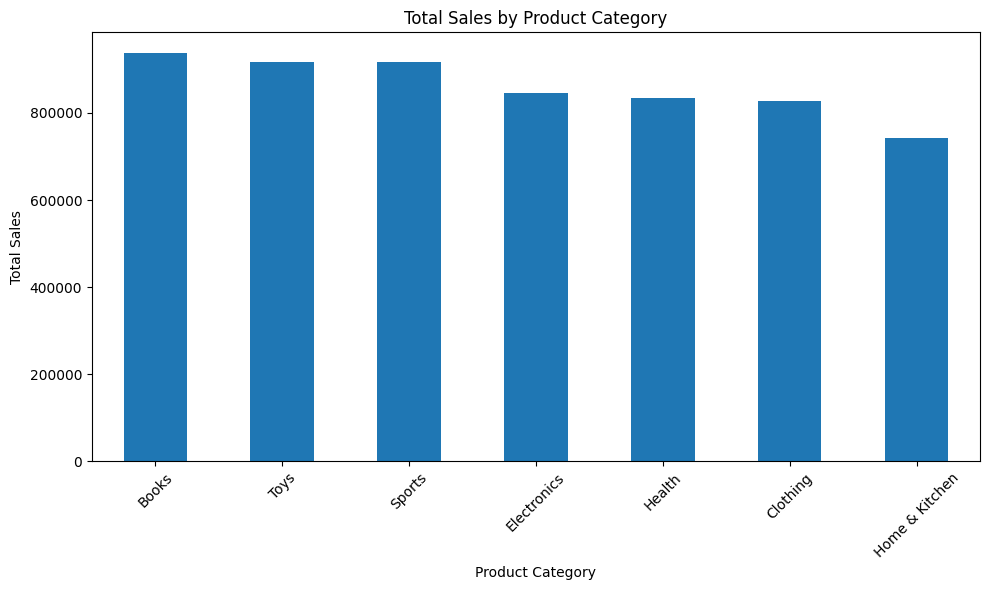

In [354]:
# Visualize total sales by category

plt.figure(figsize=(10, 6))

category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [355]:
# Calculate average sales per product by category

category_avg_sales = (
    df.groupby("category")["Total_Sales"]
    .mean()
    .sort_values(ascending=False)
)

category_avg_sales



,Total_Sales
category,
Electronics,6124.057971
Books,6092.396104
Toys,6073.516556
Health,6002.978417
Sports,5989.352941
Home & Kitchen,5937.128000
Clothing,5903.828571


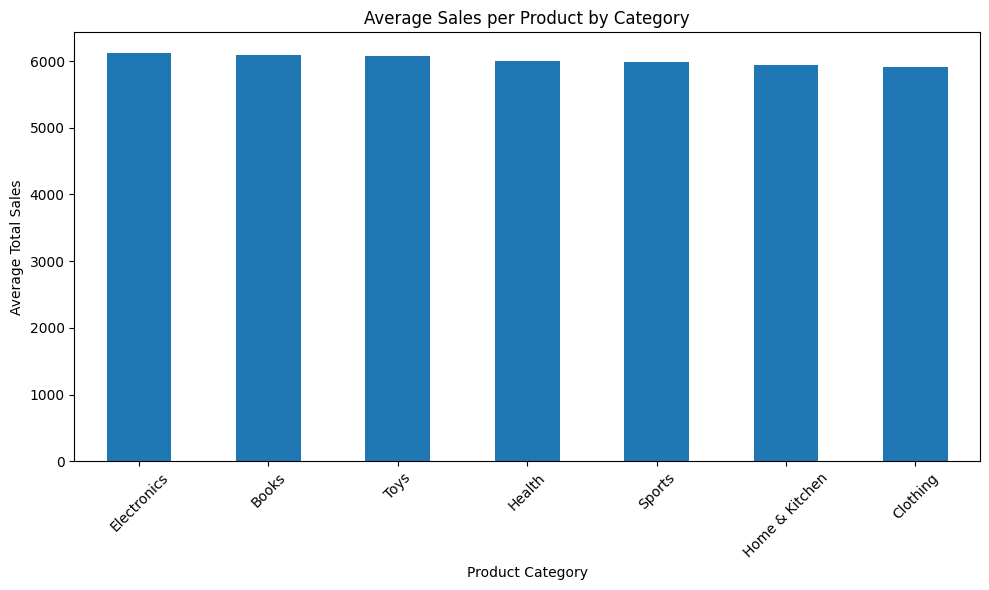

In [356]:
# Visualize average sales per product by category

plt.figure(figsize=(10, 6))

category_avg_sales.plot(kind="bar")

plt.title("Average Sales per Product by Category")
plt.xlabel("Product Category")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Why do we need both?

Imagine:

Category A → 300 products → huge total sales

Category B → 30 products  → smaller total sales

Category A may have higher total sales, simply because it has more products.

But Category B could have much higher sales per product.

That's why both metrics are useful

In [357]:
# Top 10 Products

top_10_products = (
    df.nlargest(10, "Total_Sales")
    [["product_name", "category", "Total_Sales"]]
)

top_10_products

,product_name,category,Total_Sales
223,Product_224,Electronics,9151
285,Product_286,Clothing,8921
733,Product_734,Health,8914
904,Product_905,Sports,8783
179,Product_180,Sports,8775
852,Product_853,Books,8765
238,Product_239,Health,8724
923,Product_924,Electronics,8525
936,Product_937,Electronics,8459
196,Product_197,Toys,8418


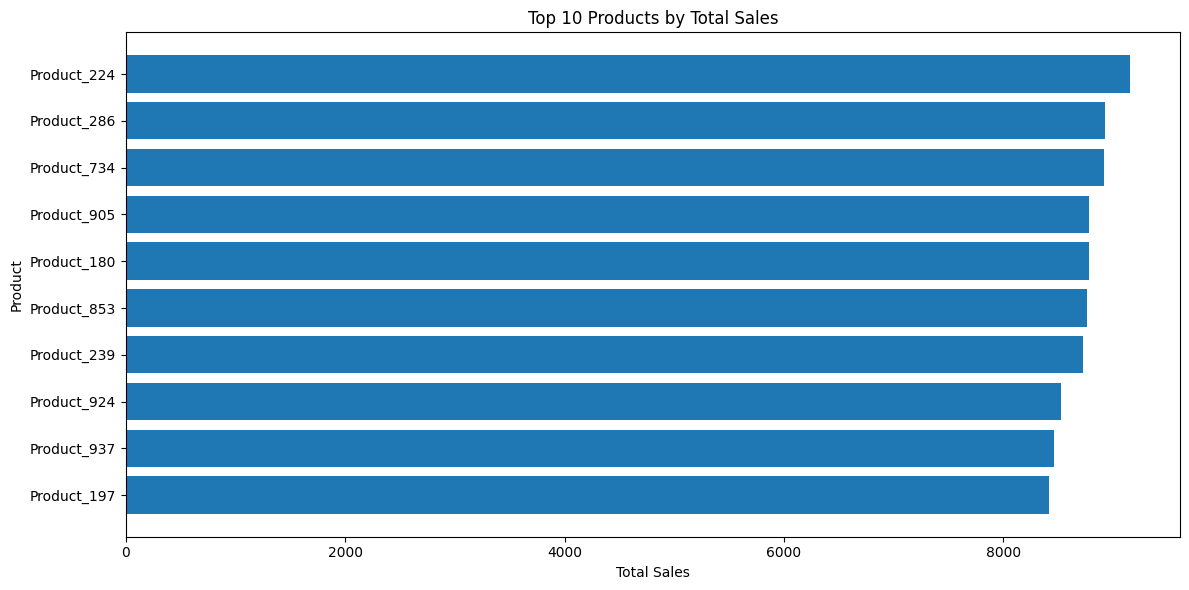

In [358]:
# Visualize top 10 products

plt.figure(figsize=(12, 6))

plt.barh(
    top_10_products["product_name"],
    top_10_products["Total_Sales"]
)

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [359]:
# Bottom 10 Products

bottom_10_products = (
    df.nsmallest(10, "Total_Sales")
    [["product_name", "category", "Total_Sales"]]
)

bottom_10_products

,product_name,category,Total_Sales
122,Product_123,Health,2972
691,Product_692,Toys,3162
785,Product_786,Books,3286
665,Product_666,Home & Kitchen,3301
135,Product_136,Home & Kitchen,3391
178,Product_179,Sports,3443
94,Product_95,Electronics,3539
814,Product_815,Health,3551
543,Product_544,Clothing,3564
624,Product_625,Toys,3641


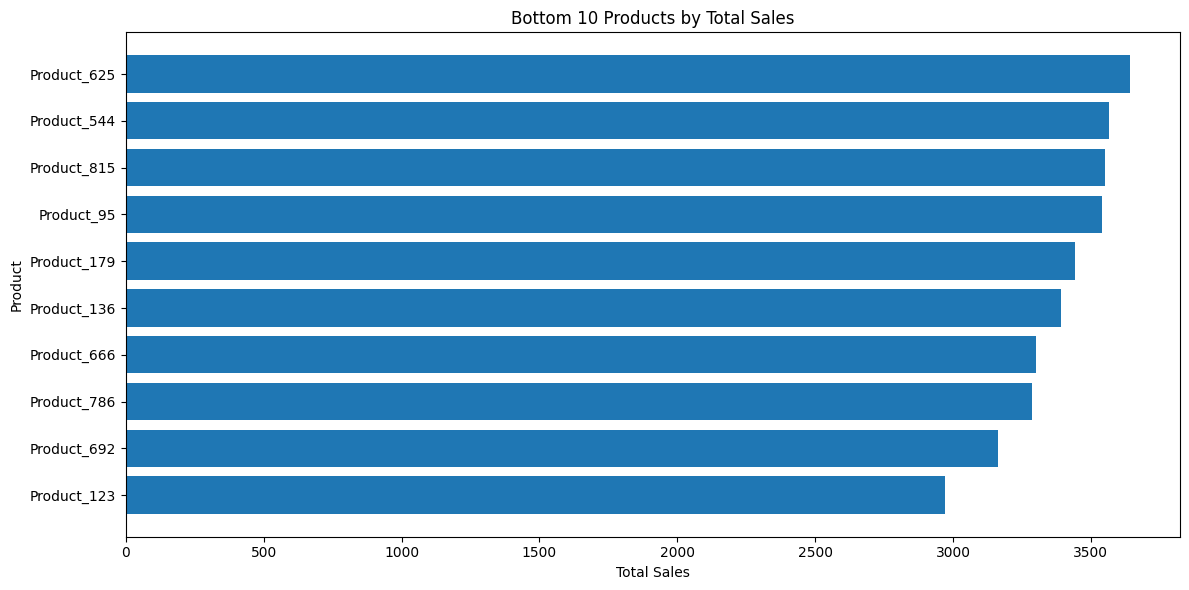

In [360]:
# Visualize bottom 10 products

plt.figure(figsize=(12, 6))

plt.barh(
    bottom_10_products["product_name"],
    bottom_10_products["Total_Sales"]
)

plt.title("Bottom 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

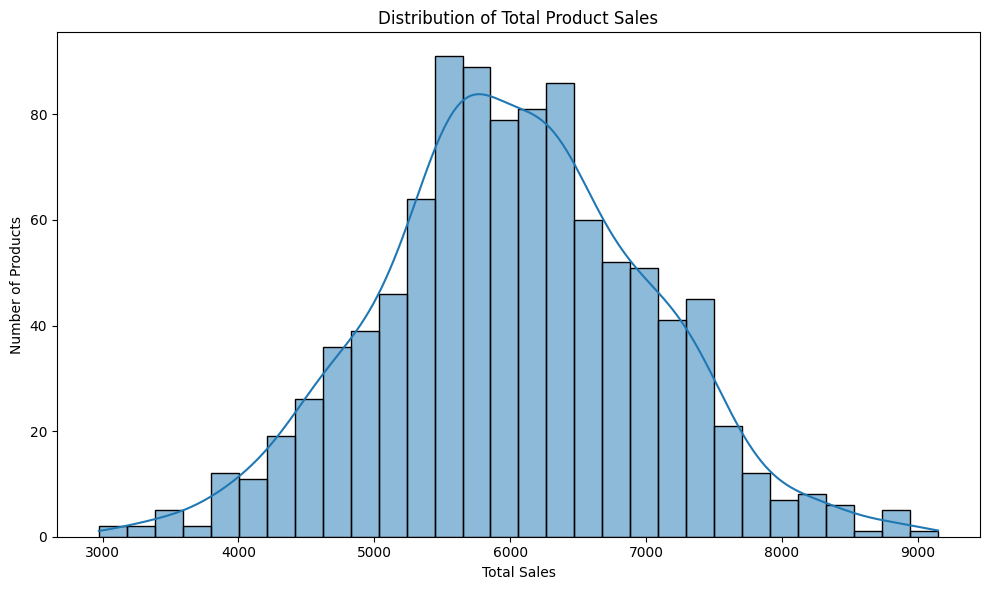

In [361]:
# Sales Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    df["Total_Sales"],
    bins=30,
    kde=True
)

plt.title("Distribution of Total Product Sales")
plt.xlabel("Total Sales")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

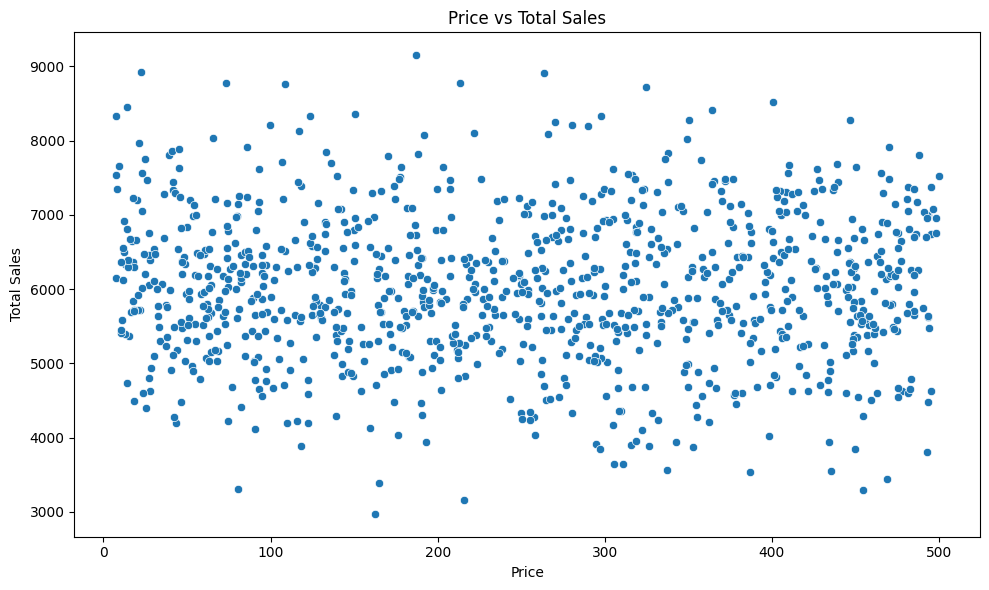

In [362]:
# Price VS Total Sales

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="price",
    y="Total_Sales"
)

plt.title("Price vs Total Sales")
plt.xlabel("Price")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()



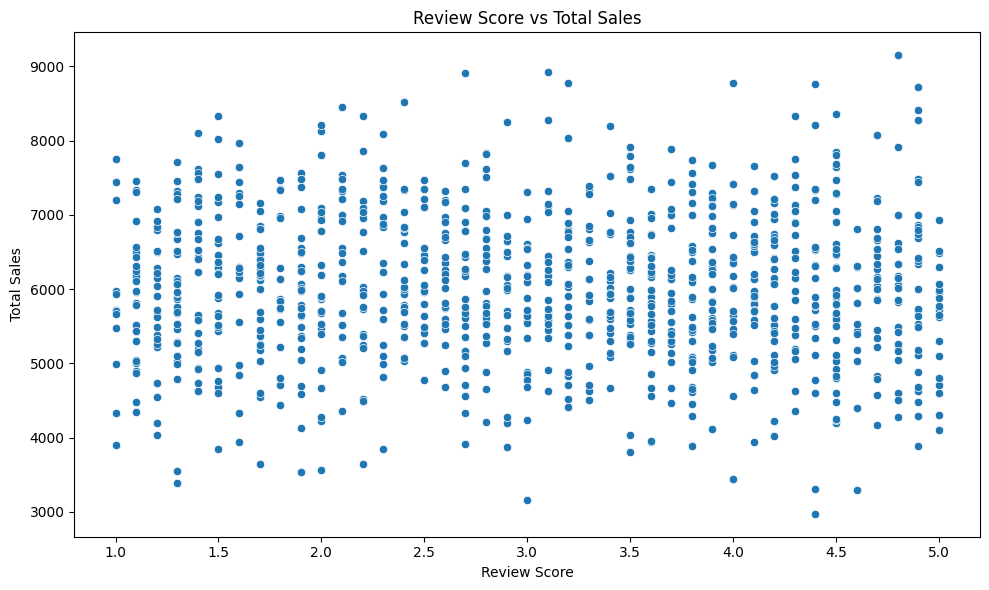

In [363]:
# review_score VS Total Sales

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="review_score",
    y="Total_Sales"
)

plt.title("Review Score vs Total Sales")
plt.xlabel("Review Score")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()



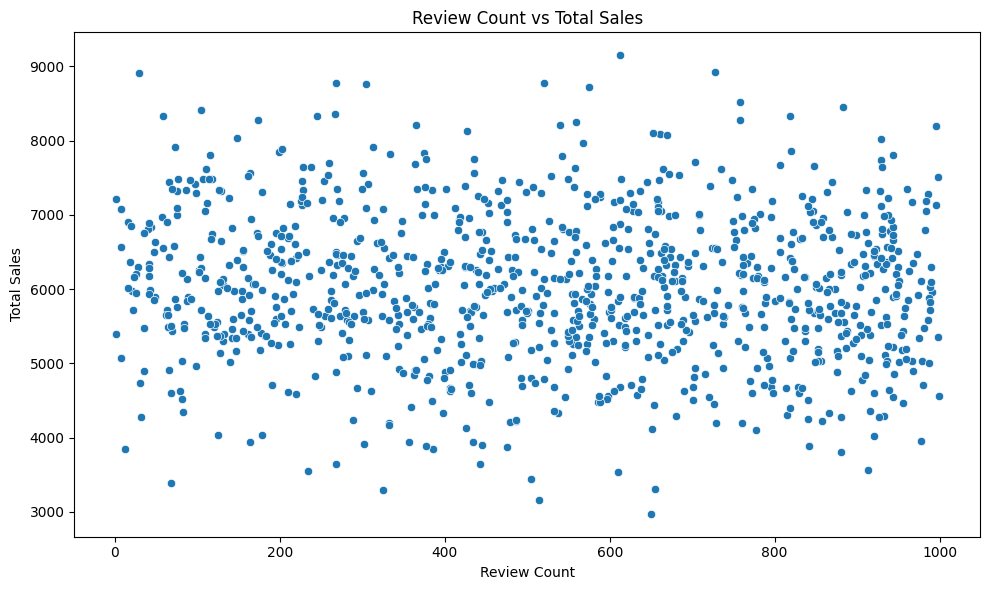

In [364]:
# Review Count VS Total Sales

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="review_count",
    y="Total_Sales"
)

plt.title("Review Count vs Total Sales")
plt.xlabel("Review Count")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [365]:
# Monthly Sales Trend

monthly_total_sales = df[monthly_sales_cols].sum()

monthly_total_sales

,0
sales_month_1,498306
sales_month_2,507661
sales_month_3,506739
sales_month_4,503823
sales_month_5,487194
sales_month_6,491653
sales_month_7,507011
sales_month_8,504569
sales_month_9,491934
sales_month_10,514798


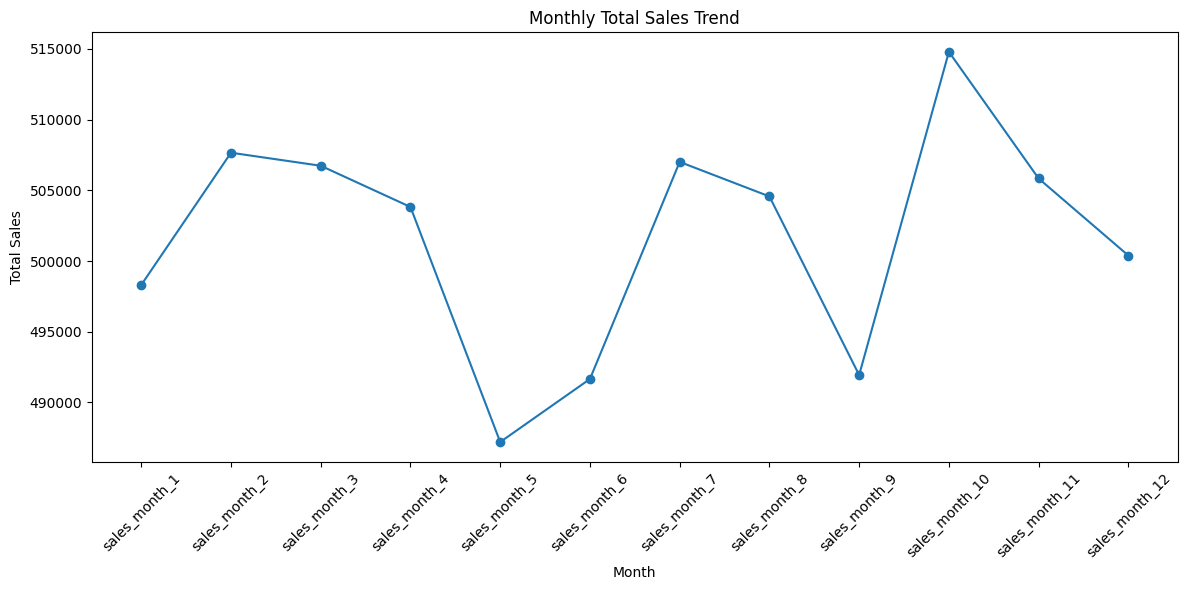

In [366]:
# Visualize monthly sales trend

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_total_sales.index,
    monthly_total_sales.values,
    marker="o"
)

plt.title("Monthly Total Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Exploratory Data Analysis Summary

### 1. Recorded Sales by Category

- Books had the largest sum of recorded Total_Sales values, followed by Toys and Sports. Home & Kitchen had the smallest sum.
- Electronics had the highest average Total_Sales per product; Clothing had the lowest.
- These are comparisons of the dataset’s recorded values, not confirmed revenue or market share.

### 2. Products with the Highest and Lowest Recorded Sales

- The 10 highest recorded product totals ranged from 8,418 to 9,151.
- The 10 lowest ranged from 2,972 to 3,641.
- Products in both groups came from several categories. This describes the selected products; it does not explain why their sales were high or low.

### 3. Sales Distribution

- Total_Sales ranged from 2,972 to 9,151. The mean was about 6,020 and the median was 5,992.
- These figures describe variation in the recorded sales values. Their business meaning depends on whether sales represents units, orders, or revenue.

### 4. Product Attributes and Total Sales

- Price, review score, and review count had weak linear correlations with Total_Sales in this dataset.
- Correlation measures linear association and does not prove cause and effect. The model results also did not show meaningful improvement over the mean-only benchmark.

### 5. Monthly Sales Values

- Total sales rose from 487,194 in Month 5 to a peak of 514,798 in Month 10, with fluctuations between months.
- Sales declined after Month 10, reaching 500,386 in Month 12.
- This describes the 12 months shown. Without calendar dates and data covering multiple years, it does not establish a lasting trend or seasonal pattern.

# Correlation Analysis

Correlation analysis helps us understand the relationships between
numerical variables in the dataset.

We will:
- Calculate correlations between numerical features
- Visualize the correlation matrix
- Examine variables related to Total Sales

In [367]:
# select numerical columns:

numeric_df = df.select_dtypes(include=np.number)

print("Number of numerical columns:", numeric_df.shape[1])
print("\nNumerical columns:")
print(numeric_df.columns.tolist())


Number of numerical columns: 22

Numerical columns:
['product_id', 'price', 'review_score', 'review_count', 'sales_month_1', 'sales_month_2', 'sales_month_3', 'sales_month_4', 'sales_month_5', 'sales_month_6', 'sales_month_7', 'sales_month_8', 'sales_month_9', 'sales_month_10', 'sales_month_11', 'sales_month_12', 'Total_Sales', 'Average_Monthly_Sales', 'Max_Monthly_Sales', 'Min_Monthly_Sales', 'Sales_Std', 'Sales_Growth']


In [368]:
# Create the correlation matrix :

correlation_matrix = numeric_df.corr()

correlation_matrix

,product_id,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,...,sales_month_9,sales_month_10,sales_month_11,sales_month_12,Total_Sales,Average_Monthly_Sales,Max_Monthly_Sales,Min_Monthly_Sales,Sales_Std,Sales_Growth
product_id,1.000000,-0.024495,-0.040197,-0.008827,0.018804,0.077879,0.032606,-0.029126,-0.005238,-0.024078,...,-0.049009,0.023967,0.044788,-0.028809,0.031946,0.031946,0.054285,-0.004233,0.025069,-0.040018
price,-0.024495,1.000000,0.028960,0.042189,-0.033860,-0.002978,-0.023203,0.044579,0.030024,-0.051430,...,-0.008224,0.038288,0.007972,0.019081,-0.015978,-0.015978,0.014863,-0.039781,0.015477,-0.049771
review_score,-0.040197,0.028960,1.000000,0.027351,0.023949,-0.076709,-0.012420,-0.016875,-0.038930,0.017519,...,0.019554,0.015707,0.002724,-0.012969,-0.018186,-0.018186,-0.011297,-0.030118,0.021510,-0.041442
review_count,-0.008827,0.042189,0.027351,1.000000,-0.019286,-0.036431,-0.029381,-0.021719,-0.013798,-0.006579,...,-0.020332,-0.063471,-0.031269,-0.026710,-0.069393,-0.069393,-0.021551,-0.045451,0.001084,0.001358
sales_month_1,0.018804,-0.033860,0.023949,-0.019286,1.000000,0.051889,0.006204,0.048705,0.016276,0.036269,...,0.042872,0.002146,0.006124,-0.036595,0.355845,0.355845,0.175859,0.179226,-0.041727,-0.294809
sales_month_2,0.077879,-0.002978,-0.076709,-0.036431,0.051889,1.000000,-0.012759,-0.100955,0.056114,0.035142,...,0.004930,-0.018488,-0.017643,0.022997,0.275786,0.275786,0.076379,0.170680,-0.072130,-0.015518
sales_month_3,0.032606,-0.023203,-0.012420,-0.029381,0.006204,-0.012759,1.000000,-0.011394,-0.009051,0.018806,...,-0.034046,0.057530,-0.010934,0.038111,0.281801,0.281801,0.128171,0.143939,-0.025848,-0.019522
sales_month_4,-0.029126,0.044579,-0.016875,-0.021719,0.048705,-0.100955,-0.011394,1.000000,-0.016243,0.046118,...,-0.017481,0.039054,0.044536,-0.032976,0.296756,0.296756,0.167528,0.124527,0.019925,0.005531
sales_month_5,-0.005238,0.030024,-0.038930,-0.013798,0.016276,0.056114,-0.009051,-0.016243,1.000000,0.036992,...,-0.020847,0.015713,0.032319,-0.041738,0.303239,0.303239,0.115084,0.157122,-0.086051,0.027485
sales_month_6,-0.024078,-0.051430,0.017519,-0.006579,0.036269,0.035142,0.018806,0.046118,0.036992,1.000000,...,0.002852,-0.000288,-0.018171,-0.053489,0.305284,0.305284,0.143222,0.135210,-0.042682,-0.040672


The values will range from:

-1  ─────────  0  ─────────  +1

Very simply:
- +1 → strong positive relationship
- 0 → little/no linear relationship
- -1 → strong negative relationship

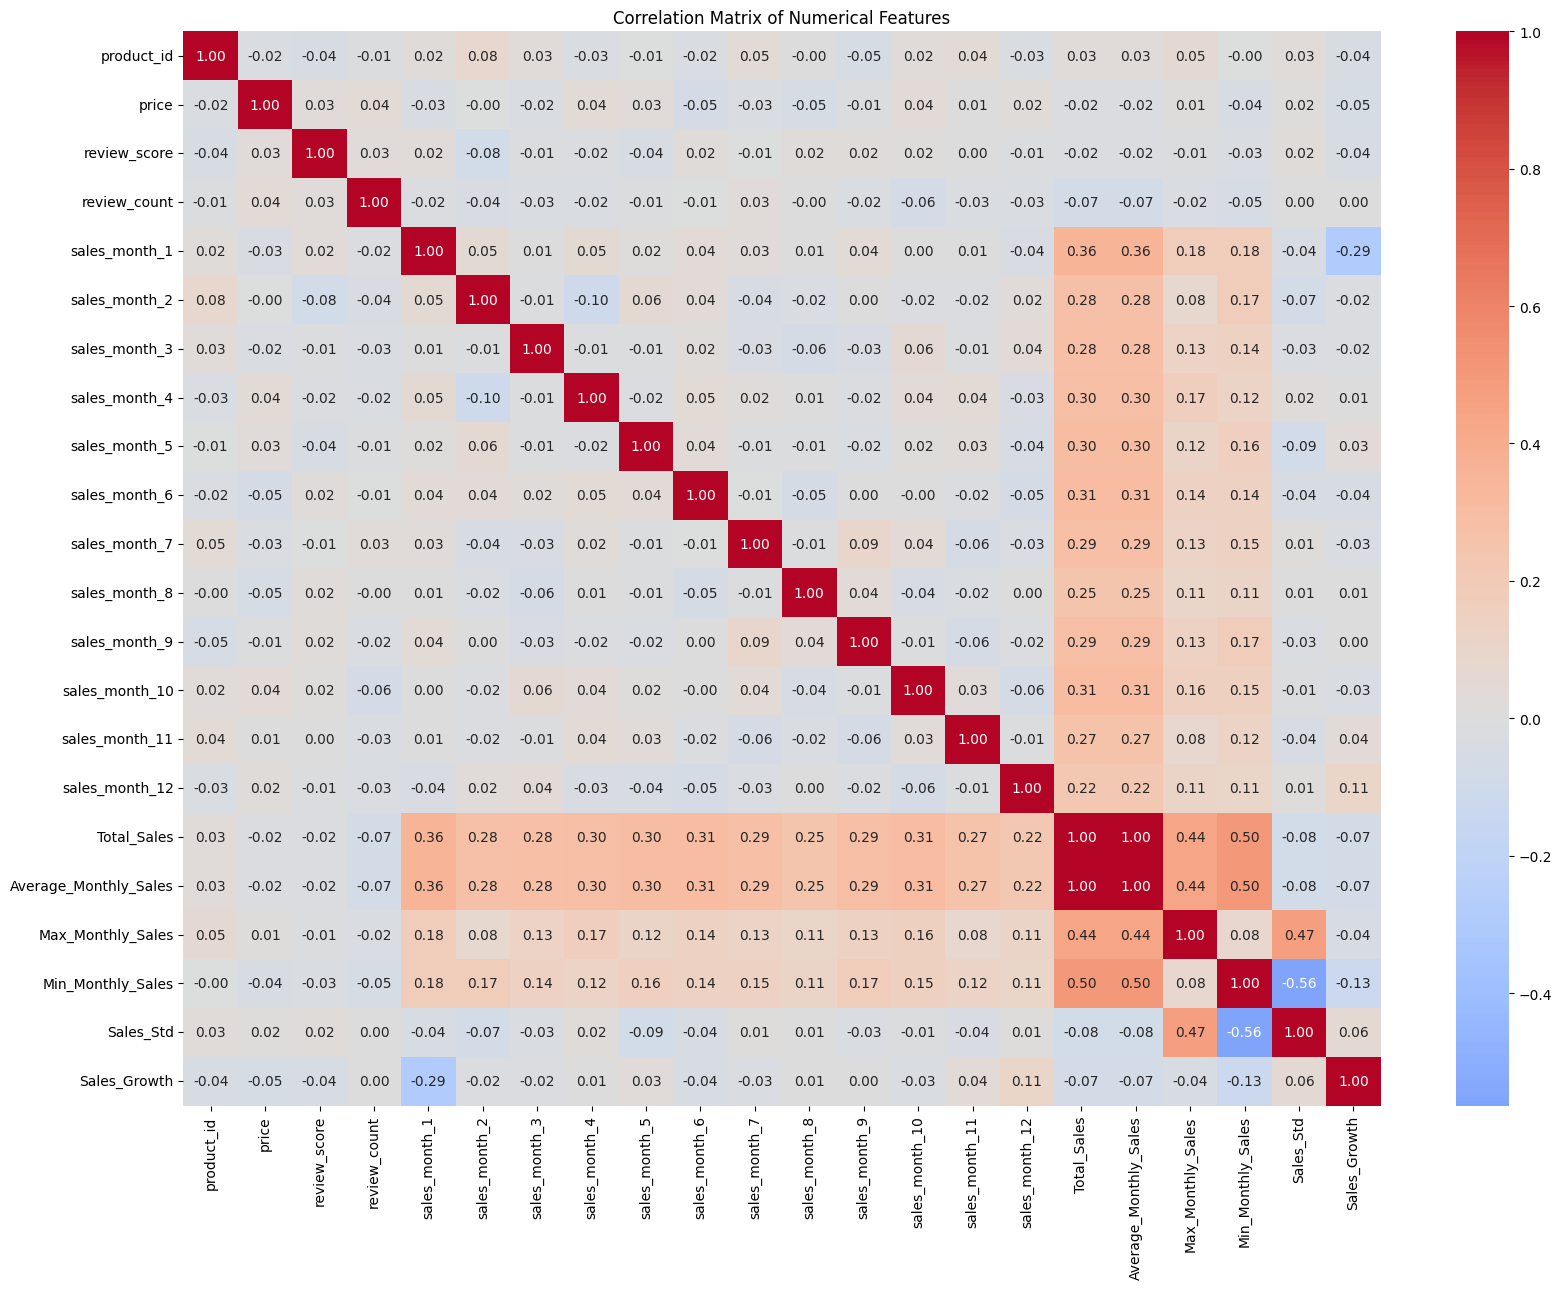

In [369]:
# Visualize the correlation matrix :
# correlation heatmap :

plt.figure(figsize=(17, 13))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()

plt.show()


In [370]:
# correlation with Total Sales :

sales_correlation = (
    correlation_matrix["Total_Sales"]
    .sort_values(ascending=False)
)

display(sales_correlation)

,Total_Sales
Average_Monthly_Sales,1.000000
Total_Sales,1.000000
Min_Monthly_Sales,0.501067
Max_Monthly_Sales,0.440474
sales_month_1,0.355845
sales_month_10,0.307326
sales_month_6,0.305284
sales_month_5,0.303239
sales_month_4,0.296756
sales_month_9,0.294303


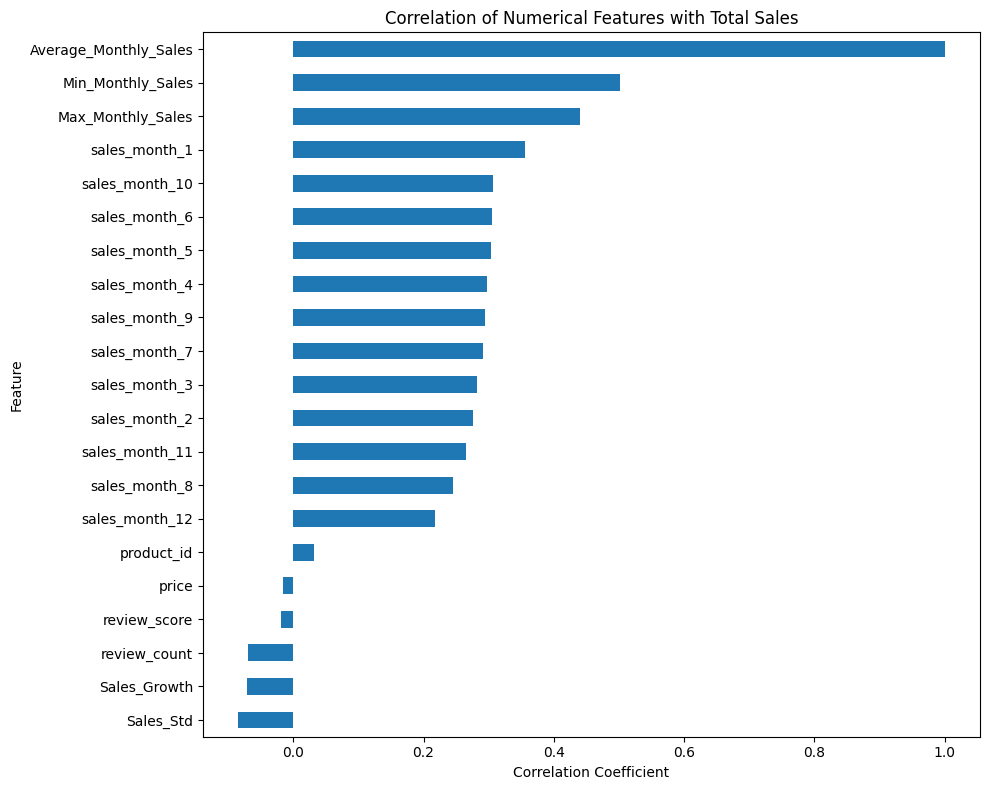

In [371]:
# Features correlated with Total Sales :

sales_correlation_without_target = (
    sales_correlation.drop("Total_Sales")
)

plt.figure(figsize=(10, 8))

sales_correlation_without_target.sort_values().plot(kind="barh")

plt.title("Correlation of Numerical Features with Total Sales")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Correlation Analysis — Key Observations

- Average Monthly Sales shows the strongest positive correlation with Total Sales.
- Max Monthly Sales and Min Monthly Sales also have strong positive relationships with Total Sales.
- Individual monthly sales variables are positively correlated with Total Sales.
- Price, Review Score, and Review Count show relatively weak relationships with Total Sales.
- Sales Growth and Sales Standard Deviation show weak negative relationships with Total Sales.
- The strong correlations of monthly sales and derived sales features are expected because they are mathematically related to Total Sales.
- Correlation indicates association, not causation.

# Machine Learning — Dataset Preparation

The objective of this stage is to determine whether product-level
characteristics can be used to predict total product sales.

Target variable:
- Total_Sales

Potential predictive features:
- Price
- Review Score
- Review Count
- Category

Sales-derived variables are excluded from the model to avoid data leakage.

In [372]:
# check actual column names:

print(df.columns.tolist())

['product_id', 'product_name', 'category', 'price', 'review_score', 'review_count', 'sales_month_1', 'sales_month_2', 'sales_month_3', 'sales_month_4', 'sales_month_5', 'sales_month_6', 'sales_month_7', 'sales_month_8', 'sales_month_9', 'sales_month_10', 'sales_month_11', 'sales_month_12', 'Total_Sales', 'Average_Monthly_Sales', 'Max_Monthly_Sales', 'Min_Monthly_Sales', 'Sales_Std', 'Best_Sales_Month', 'Sales_Growth']


In [373]:
# Select ML Features :

ml_features = [
    "price",
    "review_score",
    "review_count",
    "category"
]

target = "Total_Sales"

print("ML Features:")
print(ml_features)

print("\nTarget:")
print(target)

ML Features:
['price', 'review_score', 'review_count', 'category']

Target:
Total_Sales


Why these features?

Features & Why we use it :

price

Product pricing may be associated with sales


review_score

Customer ratings may relate to product performance


review_count

Indicates customer engagement/popularity


category

Different product categories may have different sales patterns


Total_Sales

Our prediction target


We intentionally exclude product_id and product_name because they are identifiers/text labels rather than meaningful numerical predictors.

Create X and y

Now we separate the dataset into:

X → information used to make predictions

y → what we want to predict

In [374]:
# Create FEATURES (X) AND TARGET (y)

X = df[ml_features].copy()
y = df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 4)
y shape: (1000,)


In [375]:
#  Display the first 5 rows of our ML features

X.head()

,price,review_score,review_count,category
0,190.40,1.7,220,Clothing
1,475.60,3.2,903,Home & Kitchen
2,367.34,4.5,163,Toys
3,301.34,3.9,951,Toys
4,82.23,4.2,220,Books


**Convert Category into numbers:**

Our machine learning models cannot directly understand:

Electronics,
Beauty,
Clothing,
......


We need to convert the categorical variable into numerical columns.

**We'll use One-Hot Encoding.**

In [376]:
# ONE-HOT ENCODE Category :

X_encoded = pd.get_dummies(
    X,
    columns=["category"],
    drop_first=True
)

print("Encoded features shape:", X_encoded.shape)

X_encoded.head()


Encoded features shape: (1000, 9)


,price,review_score,review_count,category_Clothing,category_Electronics,category_Health,category_Home & Kitchen,category_Sports,category_Toys
0,190.40,1.7,220,True,False,False,False,False,False
1,475.60,3.2,903,False,False,False,True,False,False
2,367.34,4.5,163,False,False,False,False,False,True
3,301.34,3.9,951,False,False,False,False,False,True
4,82.23,4.2,220,False,False,False,False,False,False


In [377]:
# Converting boolean values to integer

bool_cols = X_encoded.select_dtypes(include='bool').columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)

X_encoded.head()

,price,review_score,review_count,category_Clothing,category_Electronics,category_Health,category_Home & Kitchen,category_Sports,category_Toys
0,190.40,1.7,220,1,0,0,0,0,0
1,475.60,3.2,903,0,0,0,1,0,0
2,367.34,4.5,163,0,0,0,0,0,1
3,301.34,3.9,951,0,0,0,0,0,1
4,82.23,4.2,220,0,0,0,0,0,0


In [378]:
#  TRAIN-TEST Split :

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)


Training features: (800, 9)
Testing features: (200, 9)
Training target: (800,)
Testing target: (200,)


In [379]:
# check Target Variable :

print("Target variable: Total_Sales")

print("\nMinimum:", y.min())
print("Maximum:", y.max())
print("Mean:", y.mean())
print("Median:", y.median())

Target variable: Total_Sales

Minimum: 2972
Maximum: 9151
Mean: 6019.912
Median: 5992.0


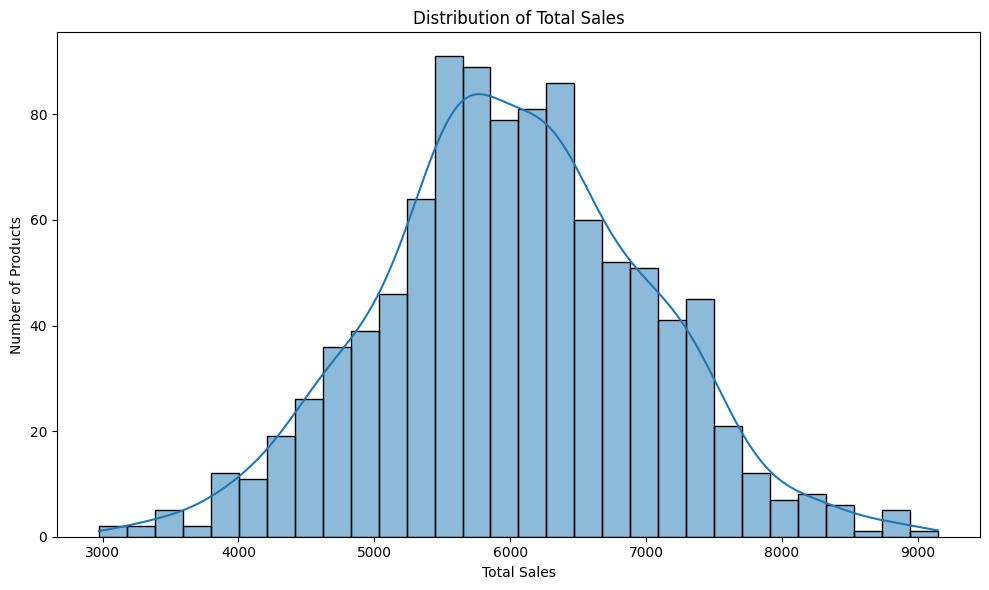

In [380]:
# Visualize target distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    y,
    bins=30,
    kde=True
)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

 The distribution seems relatively symmetrical, indicating that most products have sales clustered around the average, with fewer products having very high or very low sales.

## Machine Learning — Model Training & Evaluation

In [381]:
# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"--- Random Forest Regressor Performance ---")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R-squared (R²): {r2:.4f}")

--- Random Forest Regressor Performance ---
Mean Absolute Error (MAE): 817.52
Root Mean Squared Error (RMSE): 1,027.38
R-squared (R²): -0.1606


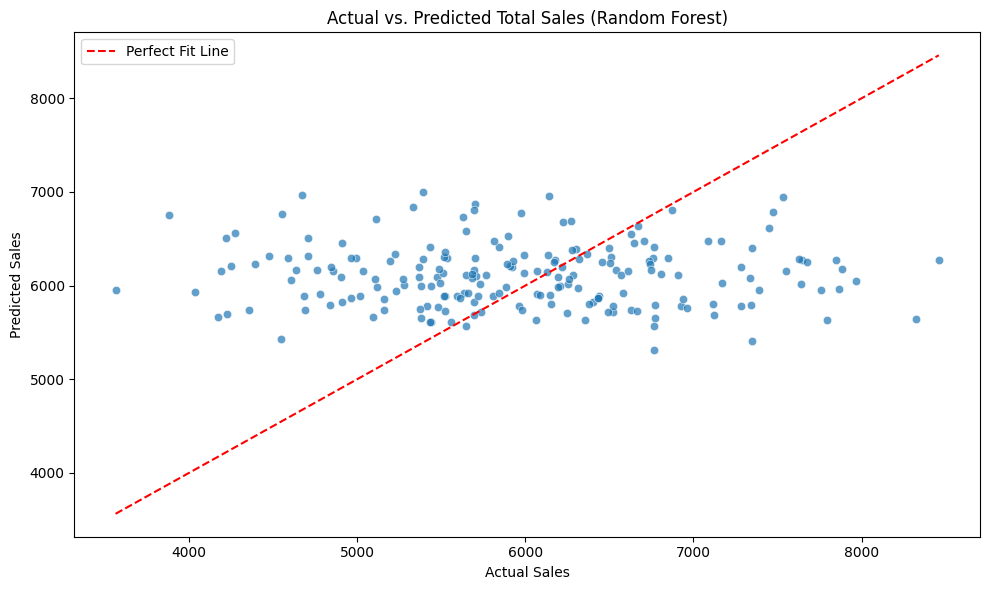

In [382]:
# Visualize Actual vs Predicted Sales
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)

# Reference line representing perfect prediction
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit Line')

plt.title("Actual vs. Predicted Total Sales (Random Forest)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [383]:
# Compare Random Forest model with simple Linear Regression baseline model :

from sklearn.linear_model import LinearRegression

# Initialize and train the Linear Regression baseline
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Calculate evaluation metrics for Linear Regression
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Display comparative metrics
performance_comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Linear Regression (Baseline)": [mae_lr, rmse_lr, r2_lr],
    "Random Forest": [mae, rmse, r2]
})
display(performance_comparison)

,Metric,Linear Regression (Baseline),Random Forest
0,MAE,777.932688,817.516200
1,RMSE,956.896757,1027.381864
2,R² Score,-0.006772,-0.160553


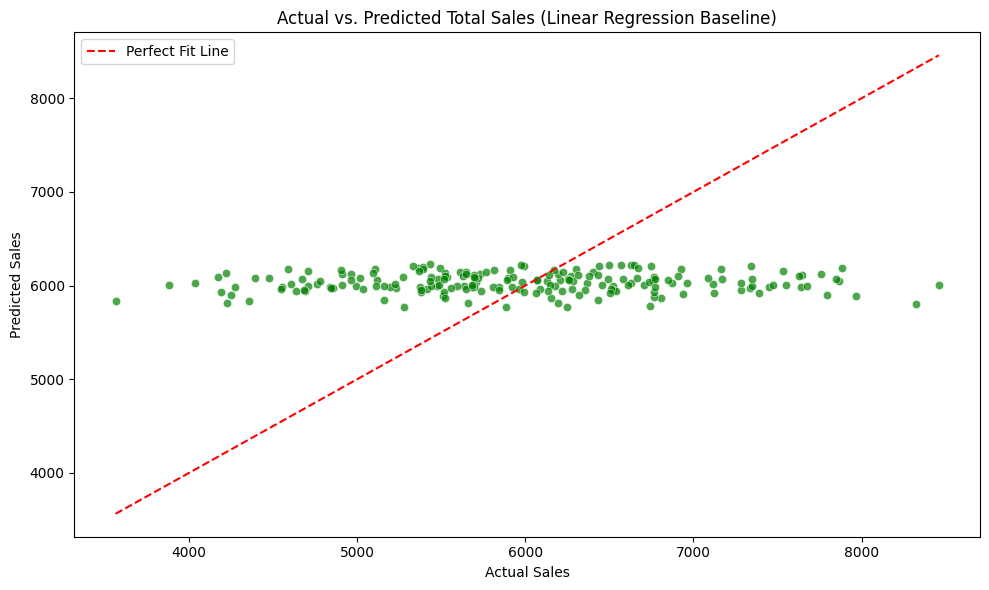

In [384]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Actual vs Predicted Sales for Linear Regression Baseline
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.7, color='green')

# Reference line representing perfect prediction
max_val_lr = max(y_test.max(), y_pred_lr.max())
min_val_lr = min(y_test.min(), y_pred_lr.min())
plt.plot([min_val_lr, max_val_lr], [min_val_lr, max_val_lr], color='red', linestyle='--', label='Perfect Fit Line')

plt.title("Actual vs. Predicted Total Sales (Linear Regression Baseline)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.legend()
plt.tight_layout()
plt.show()

,Feature,Importance
2,review_count,0.325886
0,price,0.322233
1,review_score,0.214114
3,category_Clothing,0.025878
8,category_Toys,0.025659
5,category_Health,0.022774
6,category_Home & Kitchen,0.022324
4,category_Electronics,0.022064
7,category_Sports,0.019068


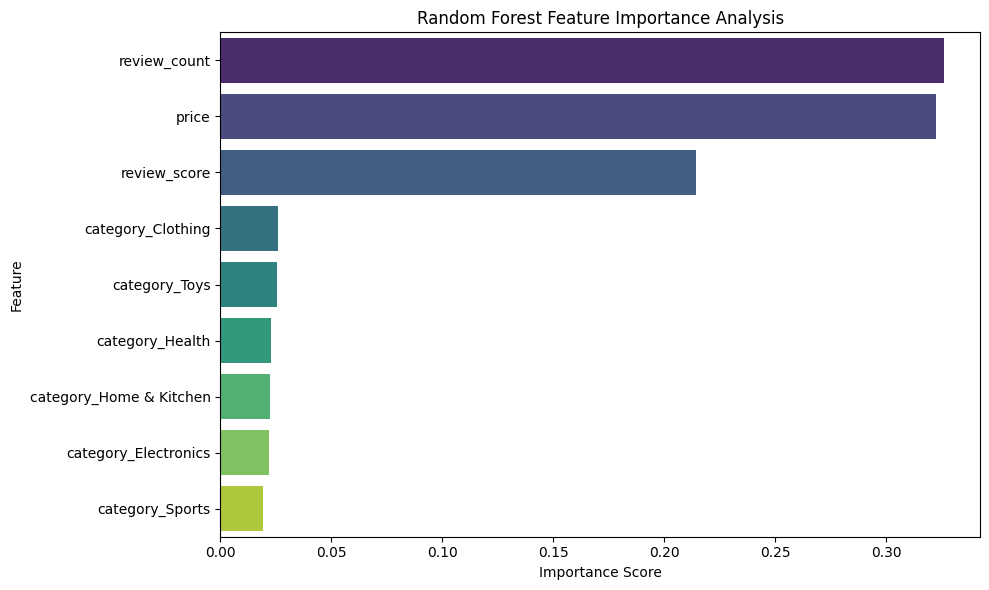

In [385]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract feature importances from the trained Random Forest model
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for easy sorting and plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the structured importances table
display(feature_importance_df)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Random Forest Feature Importance Analysis')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning & Feature Engineering to Optimize Predictions

We will use `GridSearchCV` to find optimal hyperparameters that regularize the Random Forest model (preventing it from splitting too deeply on noise) and attempt to construct basic feature interactions.

In [386]:
from sklearn.model_selection import GridSearchCV

# Create interaction features to see if combinations hold predictive power
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

# Create a Price * Review Count interaction
X_train_eng['price_x_reviews'] = X_train_eng['price'] * X_train_eng['review_count']
X_test_eng['price_x_reviews'] = X_test_eng['price'] * X_test_eng['review_count']

# Define a parameter grid focusing heavily on restricting tree growth (regularization)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 8, None],               # Shallow depths prevent memorizing noise
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize Grid Search with 5-fold Cross-Validation
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Fit Grid Search
rf_grid.fit(X_train_eng, y_train)

# Get the best estimator
best_rf = rf_grid.best_estimator_
print("Best Parameters found:", rf_grid.best_params_)

# Evaluate the optimized model
y_pred_opt = best_rf.predict(X_test_eng)

opt_mae = mean_absolute_error(y_test, y_pred_opt)
opt_mse = mean_squared_error(y_test, y_pred_opt)
opt_rmse = np.sqrt(opt_mse)
opt_r2 = r2_score(y_test, y_pred_opt)

# Compare with baseline and old RF
comparison_updated = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Linear Regression (Baseline)": [mae_lr, rmse_lr, r2_lr],
    "Original Random Forest": [mae, rmse, r2],
    "Optimized Random Forest": [opt_mae, opt_rmse, opt_r2]
})
display(comparison_updated)

Best Parameters found: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 50, 'n_estimators': 200}


,Metric,Linear Regression (Baseline),Original Random Forest,Optimized Random Forest
0,MAE,777.932688,817.516200,776.365390
1,RMSE,956.896757,1027.381864,952.783480
2,R² Score,-0.006772,-0.160553,0.001864


In [387]:
from xgboost import XGBRegressor

# Initialize and train the XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Calculate evaluation metrics for XGBoost
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print(f"--- XGBoost Regressor Performance ---")
print(f"Mean Absolute Error (MAE): {xgb_mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {xgb_rmse:,.2f}")
print(f"R-squared (R²): {xgb_r2:.4f}")

--- XGBoost Regressor Performance ---
Mean Absolute Error (MAE): 807.10
Root Mean Squared Error (RMSE): 1,002.89
R-squared (R²): -0.1059


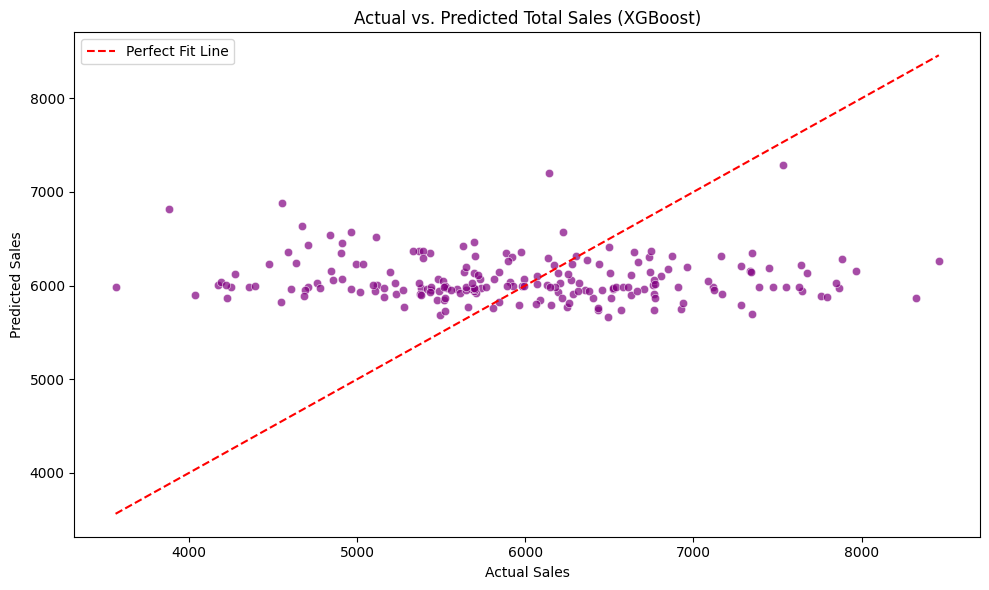

In [388]:
# Visualize Actual vs Predicted Sales for XGBoost
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.7, color='purple')

# Reference line representing perfect prediction
max_val_xgb = max(y_test.max(), y_pred_xgb.max())
min_val_xgb = min(y_test.min(), y_pred_xgb.min())
plt.plot([min_val_xgb, max_val_xgb], [min_val_xgb, max_val_xgb], color='red', linestyle='--', label='Perfect Fit Line')

plt.title("Actual vs. Predicted Total Sales (XGBoost)")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.legend()
plt.tight_layout()
plt.show()

In [389]:
# Compile an updated comprehensive comparison table
comparison_final = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Linear Regression (Baseline)": [mae_lr, rmse_lr, r2_lr],
    "Original Random Forest": [mae, rmse, r2],
    "Optimized Random Forest": [opt_mae, opt_rmse, opt_r2],
    "XGBoost Regressor": [xgb_mae, xgb_rmse, xgb_r2]
})
display(comparison_final)

,Metric,Linear Regression (Baseline),Original Random Forest,Optimized Random Forest,XGBoost Regressor
0,MAE,777.932688,817.516200,776.365390,807.101562
1,RMSE,956.896757,1027.381864,952.783480,1002.889856
2,R² Score,-0.006772,-0.160553,0.001864,-0.105879


In [390]:
 # mean-only benchmark

from sklearn.dummy import DummyRegressor

# This model ignores product details and predicts average training sales
dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(X_train, y_train)

dummy_predictions = dummy_model.predict(X_test)

dummy_mae = mean_absolute_error(y_test, dummy_predictions)
dummy_rmse = np.sqrt(
    mean_squared_error(y_test, dummy_predictions)
)
dummy_r2 = r2_score(y_test, dummy_predictions)

# Compare it with the models already in your notebook
comparison_with_dummy = pd.DataFrame({
    "Model": [
        "Mean-only benchmark",
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest",
        "XGBoost",
    ],
    "MAE": [
        dummy_mae,
        mae_lr,
        mae,
        opt_mae,
        xgb_mae,
    ],
    "RMSE": [
        dummy_rmse,
        rmse_lr,
        rmse,
        opt_rmse,
        xgb_rmse,
    ],
    "R²": [
        dummy_r2,
        r2_lr,
        r2,
        opt_r2,
        xgb_r2,
    ],
})

display(comparison_with_dummy.round(2))

,Model,MAE,RMSE,R²
0,Mean-only benchmark,775.70,955.95,-0.00
1,Linear Regression,777.93,956.90,-0.01
2,Random Forest,817.52,1027.38,-0.16
3,Tuned Random Forest,776.37,952.78,0.00
4,XGBoost,807.10,1002.89,-0.11


### Model Comparison Takeaway

The mean-only benchmark achieved an MAE of 775.70. The tuned Random Forest had a slightly lower RMSE (952.78 compared with 955.95), but its MAE was slightly higher (776.37 compared with 775.70). Its R² was approximately zero.

Overall, these small differences do not show a meaningful improvement over the mean-only benchmark. The tested product features did not demonstrate reliable sales prediction on this evaluation split.

### Model Evaluation Conclusion

The mean-only benchmark achieved an MAE of 775.70. The tuned Random Forest had a slightly lower RMSE, but its MAE was slightly higher, and its R² was approximately zero. Overall, the tested models did not meaningfully improve sales predictions over the mean-only benchmark.

This suggests that price, review score, review count, and category do not provide enough predictive information for total sales in this dataset. These results apply to this dataset and evaluation split; they do not prove that these product characteristics can never be useful for sales prediction.

Optimized Random Forest Feature Importances:


,Feature,Importance
2,review_count,0.262191
9,price_x_reviews,0.255722
0,price,0.202620
1,review_score,0.157775
6,category_Home & Kitchen,0.042668
3,category_Clothing,0.027952
8,category_Toys,0.019505
4,category_Electronics,0.015854
7,category_Sports,0.010325
5,category_Health,0.005387


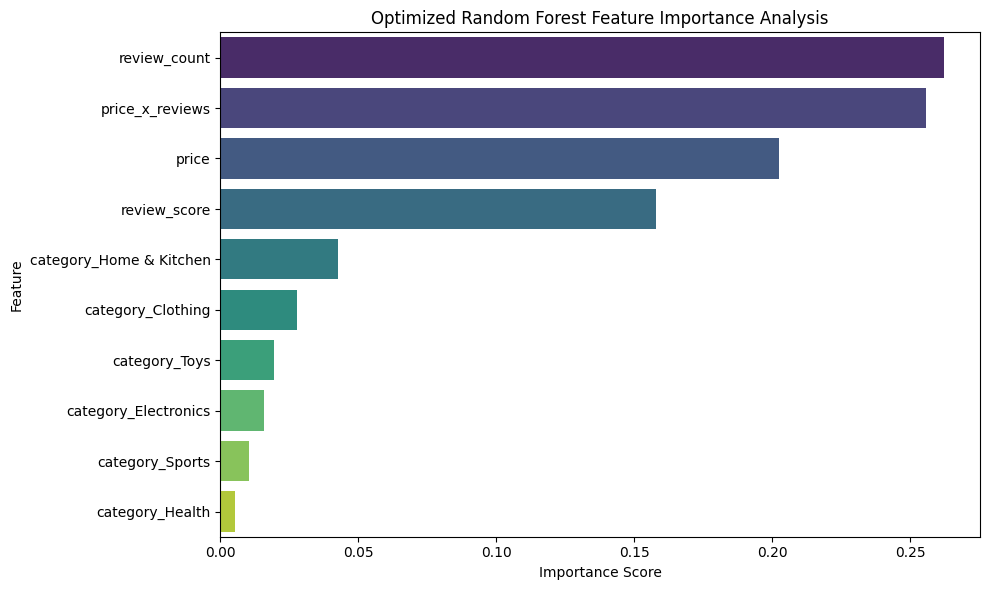

In [391]:
# Optimized Random Forest Feature Importance:

importances_opt_rf = best_rf.feature_importances_
feature_names_eng = X_train_eng.columns

feature_importance_opt_rf_df = pd.DataFrame({
    'Feature': feature_names_eng,
    'Importance': importances_opt_rf
}).sort_values(by='Importance', ascending=False)

print("Optimized Random Forest Feature Importances:")
display(feature_importance_opt_rf_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_opt_rf_df, hue='Feature', palette='viridis', legend=False)
plt.title('Optimized Random Forest Feature Importance Analysis')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

XGBoost Regressor Feature Importances:


,Feature,Importance
2,review_count,0.185063
0,price,0.167687
5,category_Health,0.150554
1,review_score,0.140268
3,category_Clothing,0.125655
6,category_Home & Kitchen,0.101733
8,category_Toys,0.067583
7,category_Sports,0.040259
4,category_Electronics,0.021199


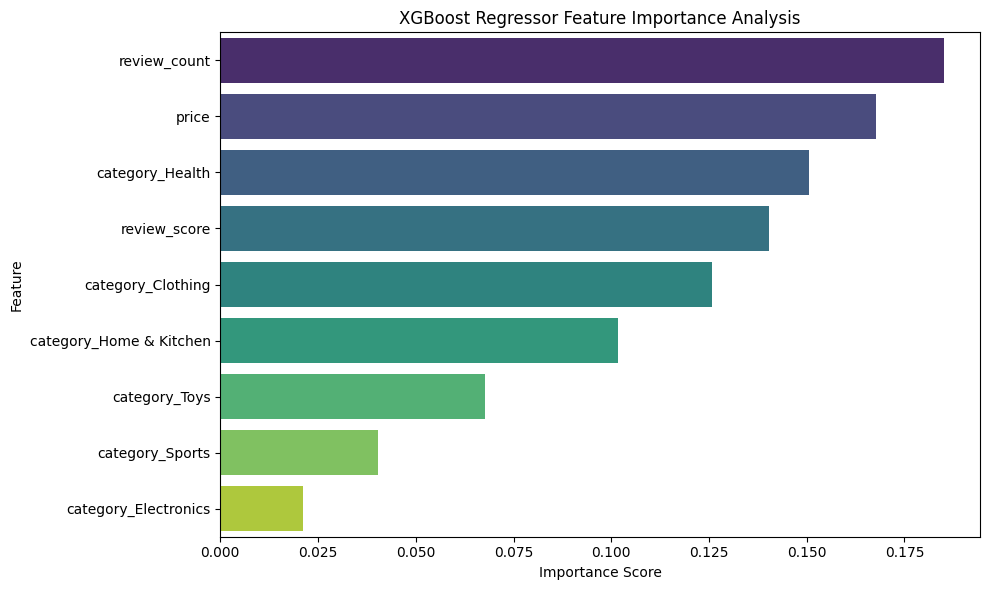

In [392]:
importances_xgb = xgb_model.feature_importances_
feature_names_xgb = X_train.columns

feature_importance_xgb_df = pd.DataFrame({
    'Feature': feature_names_xgb,
    'Importance': importances_xgb
}).sort_values(by='Importance', ascending=False)

print("XGBoost Regressor Feature Importances:")
display(feature_importance_xgb_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_xgb_df, hue='Feature', palette='viridis', legend=False)
plt.title('XGBoost Regressor Feature Importance Analysis')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Feature Importance: Cautious Interpretation

The fitted models assigned importance to features such as review count, price, and review score. These scores describe how the models used the input features; they do not show that those features cause sales to change.

Because the models did not meaningfully outperform the mean-only benchmark, these importance rankings should be treated as exploratory rather than reliable evidence of sales drivers. Better predictive results and validation on additional data would be needed to support stronger conclusions.

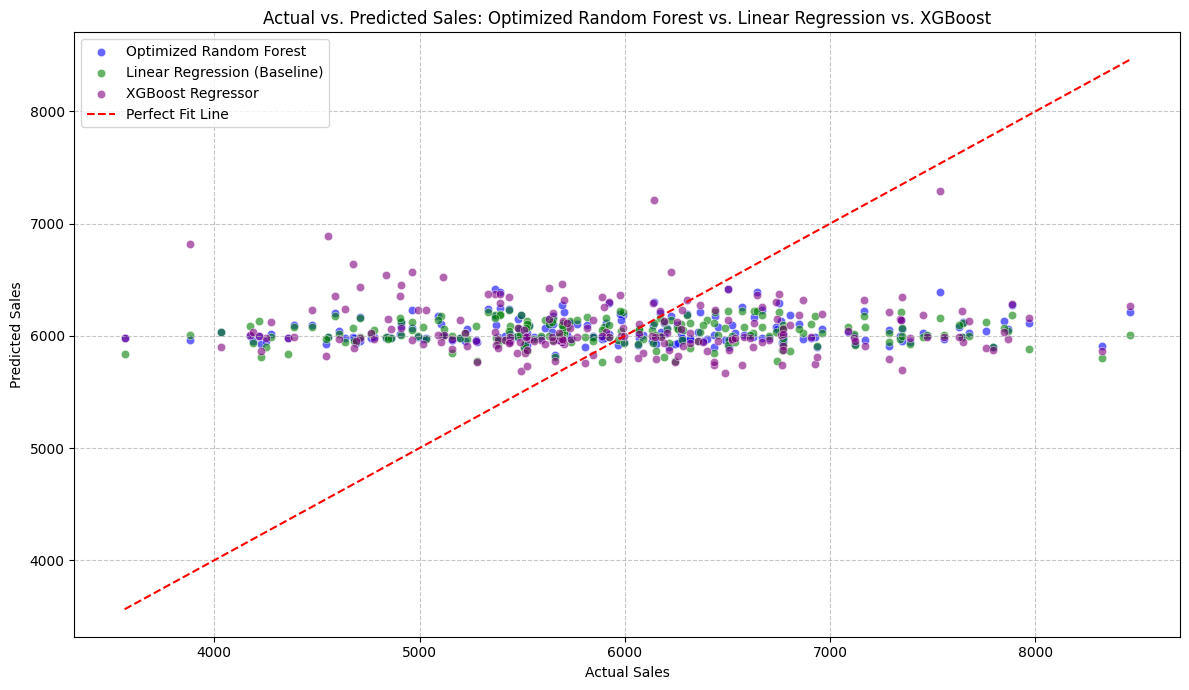

In [393]:
plt.figure(figsize=(12, 7))

# Plot for Optimized Random Forest
sns.scatterplot(x=y_test, y=y_pred_opt, alpha=0.6, label='Optimized Random Forest', color='blue')

# Plot for Linear Regression (Baseline)
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6, label='Linear Regression (Baseline)', color='green')

# Plot for XGBoost Regressor
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.6, label='XGBoost Regressor', color='purple')

# Reference line representing perfect prediction
max_val_combined = max(y_test.max(), y_pred_opt.max(), y_pred_lr.max(), y_pred_xgb.max())
min_val_combined = min(y_test.min(), y_pred_opt.min(), y_pred_lr.min(), y_pred_xgb.min())
plt.plot([min_val_combined, max_val_combined], [min_val_combined, max_val_combined], color='red', linestyle='--', label='Perfect Fit Line')

plt.title('Actual vs. Predicted Sales: Optimized Random Forest vs. Linear Regression vs. XGBoost')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The test results show that the models did not meaningfully outperform the mean-only benchmark. This evaluation predicts total sales for held-out products; it does not forecast sales for future months.

# K-Means Product Segmentation

K-Means clustering is an unsupervised machine learning technique used
to group similar products based on selected characteristics.

In this section, we will:

- Select features for clustering
- Scale the features
- Determine a suitable number of clusters
- Apply K-Means clustering
- Analyze the resulting product segments
- Visualize the clusters
- Profile each cluster

K-Means

    Input → Product information
          ↓

        K-Means
          ↓

     Finds groups itself
We don't tell it which product belongs to which group.
That's why it's called unsupervised learning.

In [394]:
# Select features for clustering

clustering_features = [
    "Total_Sales",
    "price",
    "review_score",
    "review_count"
]

cluster_data = df[clustering_features].copy()

print("Features selected for clustering:")
print(clustering_features)

print("\nshape of clustering dataset:", cluster_data.shape)


Features selected for clustering:
['Total_Sales', 'price', 'review_score', 'review_count']

shape of clustering dataset: (1000, 4)


**"I selected Price, Review Score, Review Count, and Total Sales because they represent different dimensions of product performance: pricing, customer perception, customer engagement, and commercial performance."**

If we give these raw numbers to K-Means, Total Sales could dominate the distance calculation simply because its numbers are much larger.

We want each feature to have a fair opportunity to influence the clustering.

Scaling changes the numbers onto a comparable scale. already imported StandardScaler at the beginning.



In [395]:
# feature scaling:

scaler = StandardScaler()

cluster_data_scaled = scaler.fit_transform(cluster_data)

print("original data shape:", cluster_data.shape)
print("scaled data shape:", cluster_data_scaled.shape)


original data shape: (1000, 4)
scaled data shape: (1000, 4)


**Standardization puts numerical features on a comparable scale so that features with larger numerical values don't dominate distance-based algorithms such as K-Mea**ns.

In [396]:
# verifying the scaling :
#check first 5 rows after scaling:

pd.DataFrame(
    cluster_data_scaled,
    columns=clustering_features
).head()

,Total_Sales,price,review_score,review_count
0,0.404413,-0.396284,-1.134064,-1.086405
1,0.007147,1.576932,0.147268,1.334476
2,-0.443559,0.827912,1.257755,-1.288440
3,-1.006185,0.371278,0.745222,1.504611
4,0.074702,-1.144680,1.001489,-1.086405


What does 0.40 or -1.13 mean?

These are not the original sales, price, rating, or review numbers anymore.

They are standardized values showing how far each product is from the average.

Think of:

  0   around the average,  
       +  above the average,                                    
             -  below the average

So scaling has not changed the relative information. It has simply put the variables onto a comparable scale.

-- Now comes one of the most important questions in K-Means:

How many groups should we make?

We don't want to randomly choose a number.
We'll use something called the Elbow Method.

The idea:
 K-Means calculates something called inertia.

 How different the products inside each cluster are from each other.

**Lower inertia = products are more similar.**

At some point the improvement starts becoming small.
That bend is called the elbow.

In [397]:
# Calculate inertia :
# Elbow method :

inertia_values = []

# Test different numbers of clusters
for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_data_scaled)

    inertia_values.append(kmeans.inertia_)

print("Inertia values:")
print(inertia_values)


Inertia values:
[3235.6368794823256, 2744.312696644165, 2354.2256042504287, 2074.443586138471, 1904.9814881489822, 1744.7528213343253, 1597.4758372100898, 1487.5541777318842, 1390.5629273462237]


**We're looking for the point where the improvement starts becoming noticeably smaller — the elb**ow.

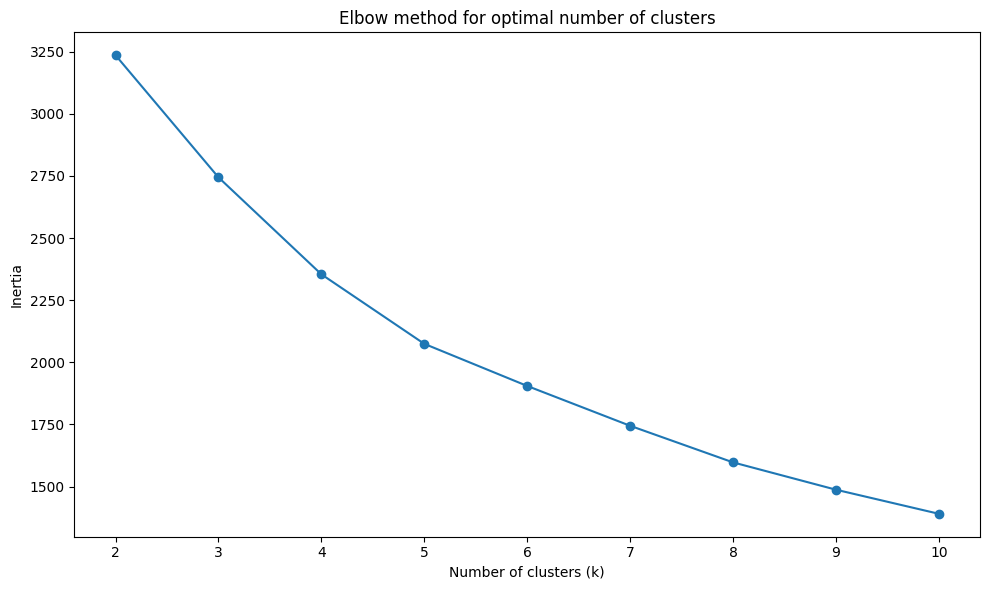

In [398]:
# Create the elbow cure :

k_values = range(2,11)

plt.figure(figsize=(10, 6))
plt.plot(
    k_values,
    inertia_values,
    marker="o"
)

plt.title("Elbow method for optimal number of clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [399]:
# Creating K-Means model :
#now we're going to tell K-Means: "Create 5 groups of similar products"

kmeans_model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans_model.fit(cluster_data_scaled)

print("K-Means model trained successfully!")


K-Means model trained successfully!


We're asking the algorithm to divide the products into 5 groups.

1,000 products --> K-Means --> C0, C1, C2, C3, C4


**Assign Each Product to a Cluster**:

Our K-Means model has now created 5 groups, but our original df doesn't yet know which product belongs to which group.

In [400]:
# Assign Clusters to products :

df["Cluster"] = kmeans_model.labels_

print("Cluster assignment completed!")

print("\nFirst 10 cluster assignments:")

print(df[["product_name", "Cluster"]].head(10))


Cluster assignment completed!

First 10 cluster assignments:
  product_name  Cluster
0    Product_1        3
1    Product_2        4
2    Product_3        1
3    Product_4        0
4    Product_5        0
5    Product_6        3
6    Product_7        0
7    Product_8        4
8    Product_9        2
9   Product_10        2


Count Products in Each Cluster:

The first question is:

How many products did K-Means put into each group?

This helps us see whether the clusters are reasonably populated.

In [401]:
# Cluster Size:

cluster_counts = df["Cluster"].value_counts().sort_index()

print("Number of products in each cluster:")
print(cluster_counts)

Number of products in each cluster:
Cluster
0    230
1    217
2    169
3    211
4    173
Name: count, dtype: int64


Profile the Clusters:

This is one of the most important steps in our K-Means analysis.

We'll calculate the average values of our four clustering features for each cluster:

Total_Sales

Price

Review Score

Review Count

This allows us to understand the characteristics of each group.

In [402]:
# Cluster Profiling :

cluster_profile = (
    df.groupby("Cluster")[
        [
            "Total_Sales",
            "price",
            "review_score",
            "review_count"
        ]
    ]
    .mean()
    .round(2)
)

display(cluster_profile)

,Total_Sales,price,review_score,review_count
Cluster,,,,
0,5650.76,127.97,3.97,661.34
1,6064.99,347.16,3.71,259.05
2,5093.66,305.08,1.89,642.81
3,6576.52,125.32,2.06,352.33
4,6680.13,375.20,3.21,781.54


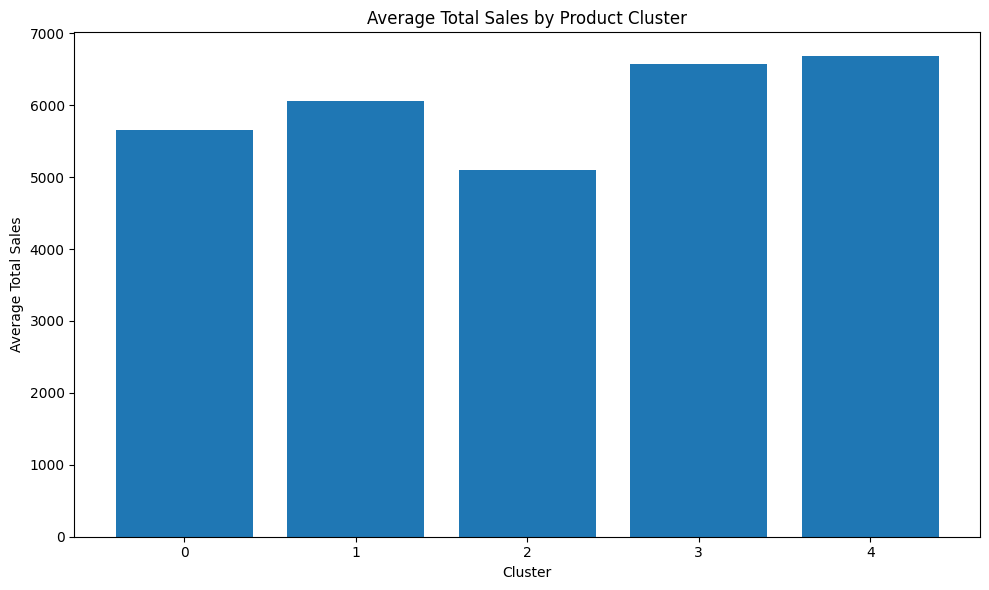

In [403]:
# Average Sales By Cluster :

cluster_sales = cluster_profile["Total_Sales"]

plt.figure(figsize=(10, 6))

plt.bar(
    cluster_sales.index.astype(str),
    cluster_sales.values
)

plt.title("Average Total Sales by Product Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average Total Sales")

plt.tight_layout()
plt.show()

**Cluster Profile Heatmap** : ( a heatmap will make our cluster profiles much easier to compare.)

Our variables have very different units:

Sales   → thousands

Price   → hundreds

Rating  → 1–5

Reviews → hundreds

So we'll use the scaled cluster averages for the heatmap.

In [404]:
# Create scaled cluster profile for comparison :

cluster_profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

cluster_profile_scaled = cluster_profile_scaled.round(2)
display(cluster_profile_scaled)


,Total_Sales,price,review_score,review_count
Cluster,,,,
0,-0.61,-1.19,1.18,0.61
1,0.09,0.84,0.87,-1.41
2,-1.56,0.45,-1.27,0.52
3,0.95,-1.21,-1.07,-0.94
4,1.13,1.10,0.29,1.22


What does this do?

It puts the four measurements onto a comparable scale for visualization.

For example:

+1.5 → relatively high

 0.0 → around average

-1.5 → relatively low

It does not change our original cluster profile.

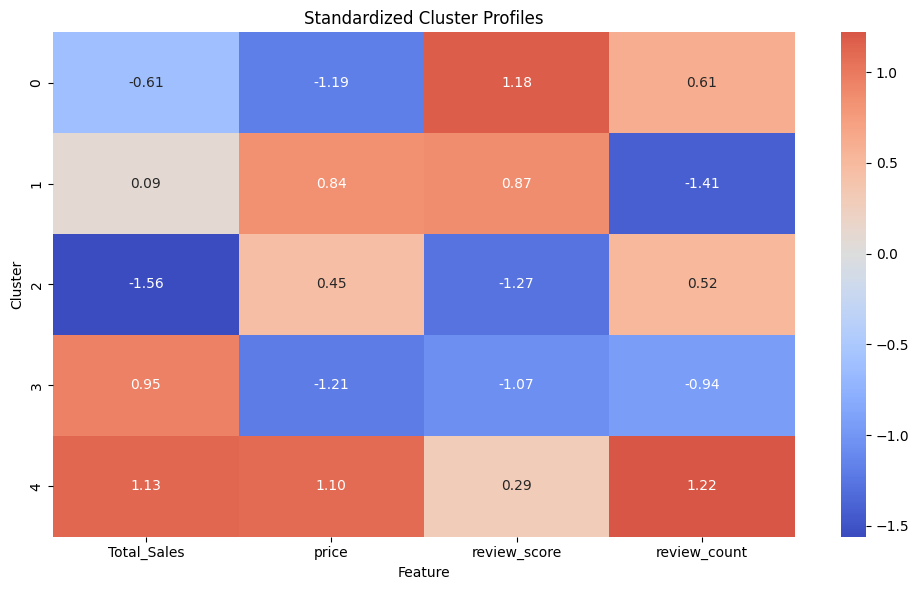

In [405]:
# Cluster Profile Heatmap :

plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Cluster Profiles")
plt.xlabel("Feature")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

In [406]:
## Business Cluster Summary :

cluster_summary = cluster_profile.copy()

cluster_summary["Product_Count"] = cluster_counts

cluster_summary["Sales_Rank"] = (
    cluster_summary["Total_Sales"]
    .rank(ascending=False, method="min")
    .astype(int)
)

display(
    cluster_summary.sort_values("Sales_Rank")
)

,Total_Sales,price,review_score,review_count,Product_Count,Sales_Rank
Cluster,,,,,,
4,6680.13,375.20,3.21,781.54,173,1
3,6576.52,125.32,2.06,352.33,211,2
1,6064.99,347.16,3.71,259.05,217,3
0,5650.76,127.97,3.97,661.34,230,4
2,5093.66,305.08,1.89,642.81,169,5


We're adding Sales Rank only as a descriptive reference.

It doesn't mean:

"Rank 1 = best cluster."

It simply means:

"This cluster has the highest average Total Sales among the identified clusters."

**Visualize Cluster Sizes:**

**How many products belong to each segment?**

(This is useful because a segment with 5 products means something very different from a segment containing 230 products.)

Text(0, 0.5, 'Number of Products')

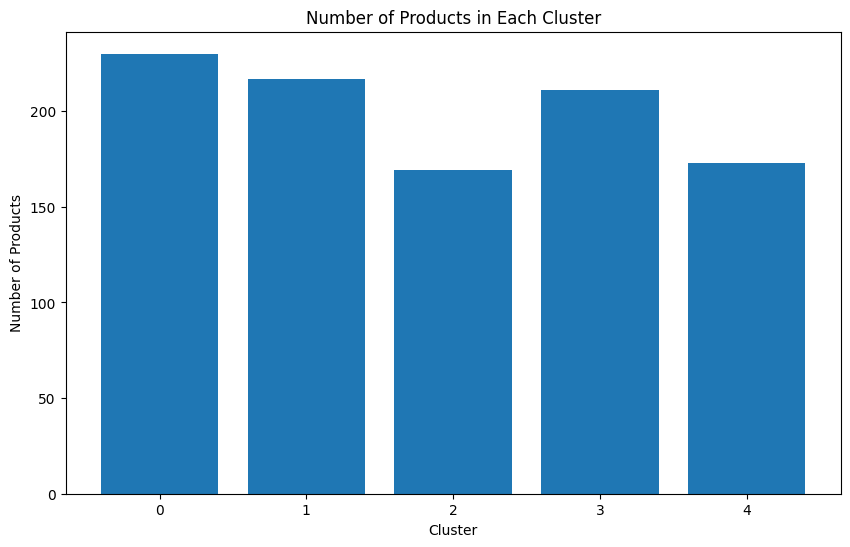

In [407]:
# Cluster size visualization :


plt.figure(figsize=(10, 6))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Number of Products in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Products")

This is a useful descriptive observation, but remember: cluster size doesn't tell us which segment is more valuable. We need to combine size with sales, price, rating, and reviews.

**Visualize the Clusters in 2D**:

Our K-Means model uses 4 features:

Total_Sales

price

review_score

review_count

We can't easily draw a 4-dimensional chart on a normal 2D screen.

So we'll use PCA (Principal Component Analysis) to compress the 4 dimensions into 2 dimensions for visualization.

4 features
    --
PCA
    --
2 dimensions
    --
2D scatter plot

In [408]:
from sklearn.decomposition import PCA

# PCA For 2D Cluster Visualization :

pca = PCA(n_components=2)

cluster_data_pca = pca.fit_transform(cluster_data_scaled)

print("Original number of features:", cluster_data_scaled.shape[1])
print("PCA dimensions:", cluster_data_pca.shape[1])

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal variance explained by 2 components:",
      pca.explained_variance_ratio_.sum())

Original number of features: 4
PCA dimensions: 2

Explained variance ratio:
[0.2764115  0.24920746]

Total variance explained by 2 components: 0.525618968243362


The explained variance tells us how much of the information contained in those four variables is represented by the two dimensions.

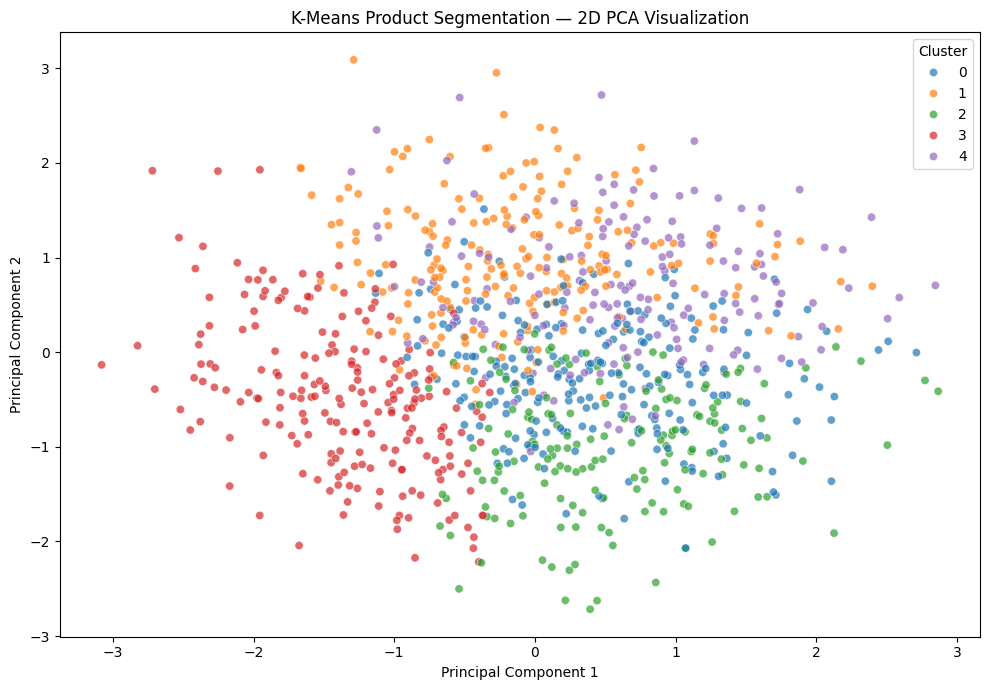

In [409]:
# 2D Cluster Visualization :

pca_df = pd.DataFrame(
    cluster_data_pca,
    columns=["pc1", "pc2"]
)

pca_df["Cluster"] = df["Cluster"].values

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="pc1",
    y="pc2",
    hue="Cluster",
    palette="tab10",
    legend='full',
    alpha=0.7
)

plt.title("K-Means Product Segmentation — 2D PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

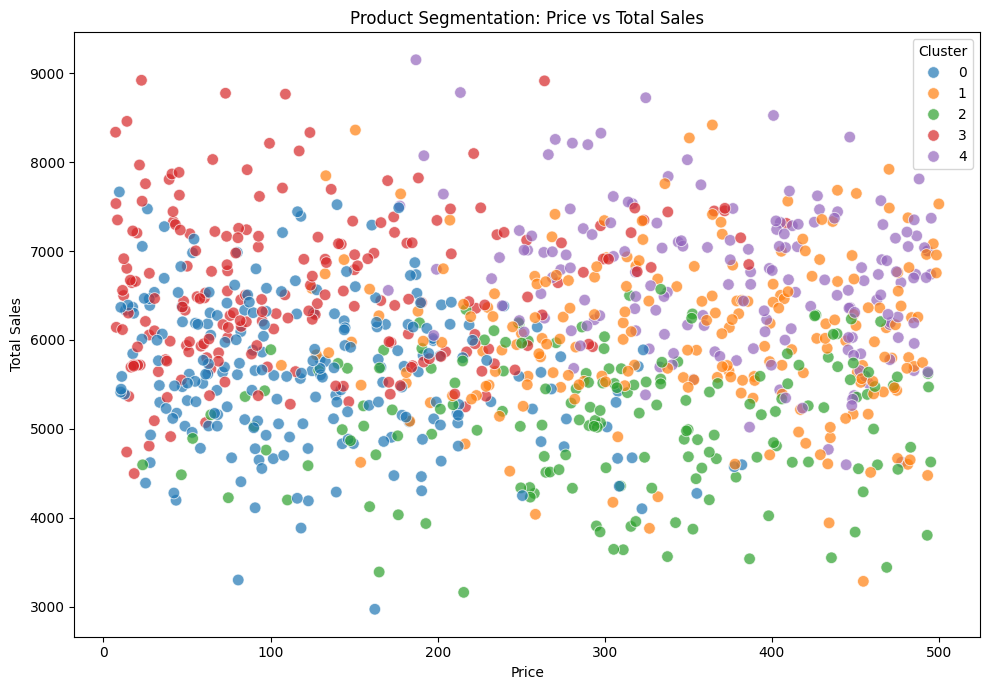

In [410]:
# Price VS Sales by Cluster :

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="price",
    y="Total_Sales",
    hue="Cluster",
    palette="tab10",
    s=70,
    alpha=0.7
)

plt.title("Product Segmentation: Price vs Total Sales")
plt.xlabel("Price")
plt.ylabel("Total Sales")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

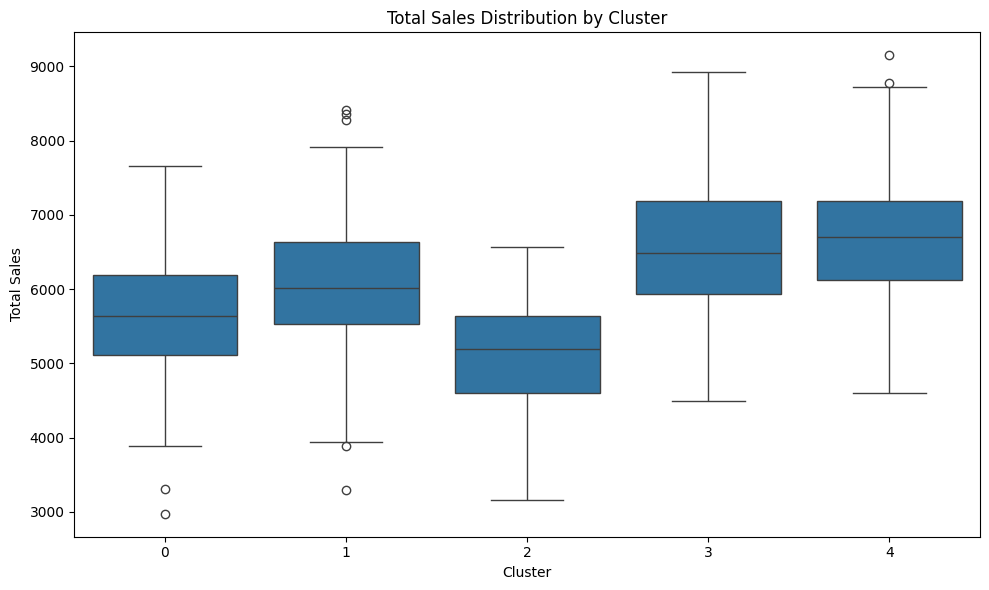

In [411]:
# Box Plot : Sales Distribution By Cluster
# A box plot helps us understand the distribution, not just the average.


plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Cluster",
    y="Total_Sales"
)

plt.title("Total Sales Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

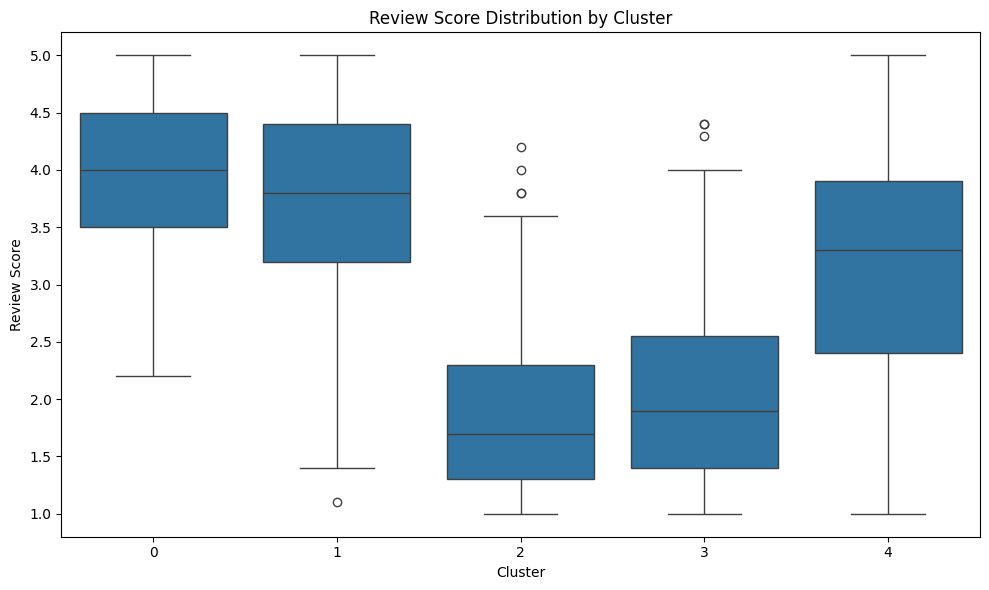

In [412]:
# Rating Distribution By Cluster :

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Cluster",
    y="review_score"
)

plt.title("Review Score Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Review Score")

plt.tight_layout()
plt.show()

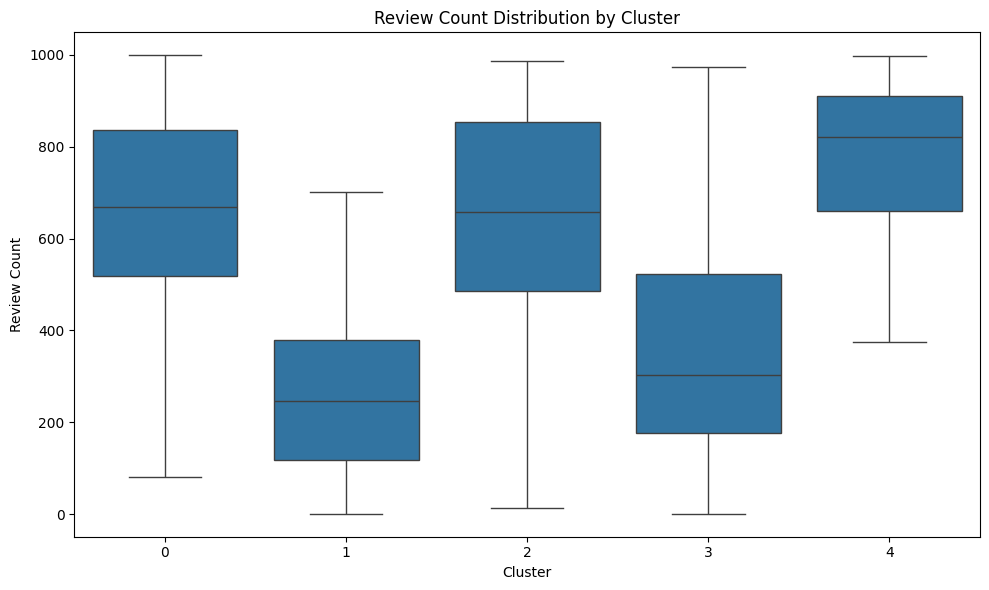

In [413]:
# Review Count Distribution By Cluster :

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Cluster",
    y="review_count"
)

plt.title("Review Count Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Review Count")

plt.tight_layout()
plt.show()

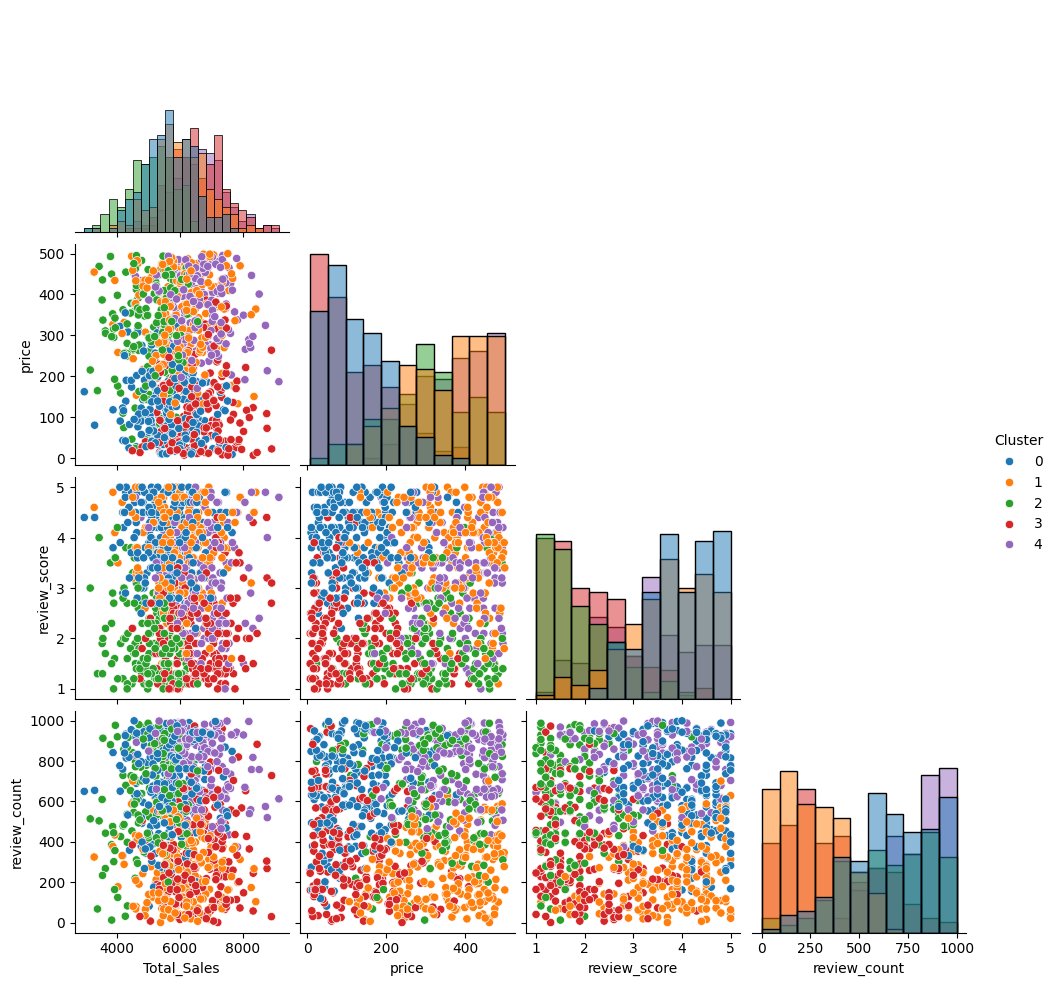

In [414]:
# pairplot of clustering features :
# A pairplot lets us see relationships between: (Total Sales, Price, Rating, Review Count all together.)


pairplot_data = df[
    [
        "Total_Sales",
        "price",
        "review_score",
        "review_count",
        "Cluster"
    ]
].copy()

sns.pairplot(
    pairplot_data,
    hue="Cluster",
    palette="tab10",
    corner=True,
    diag_kind="hist"
)

plt.show()

**Cluster Quality: Silhouette Score**

So far we've used the Elbow Method to select K=5.

But we can also use the Silhouette Score to evaluate how well-separated the clusters are.

**It ranges approximately from:**

**-1 → poor separation**

**0 → overlapping clusters**

**+1 → strong separation**

We'll calculate it for our chosen K=5.

In [415]:
# Silhouette Score :

from sklearn.metrics import silhouette_score

silhouette_k5 = silhouette_score(
    cluster_data_scaled,
    kmeans_model.labels_
)

print("Silhouette Score for K=5:", silhouette_k5)

Silhouette Score for K=5: 0.21017683800337092


In [416]:
# Silhouette Score For Diff K Values :

silhouette_scores = []

for k in range(2, 11):

    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_temp = kmeans_temp.fit_predict(cluster_data_scaled)

    score = silhouette_score(
        cluster_data_scaled,
        labels_temp
    )

    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "K": range(2, 11),
    "Silhouette_Score": silhouette_scores
})

display(silhouette_results)

,K,Silhouette_Score
0,2,0.188517
1,3,0.186889
2,4,0.205049
3,5,0.210177
4,6,0.205162
5,7,0.202279
6,8,0.209308
7,9,0.204197
8,10,0.207335


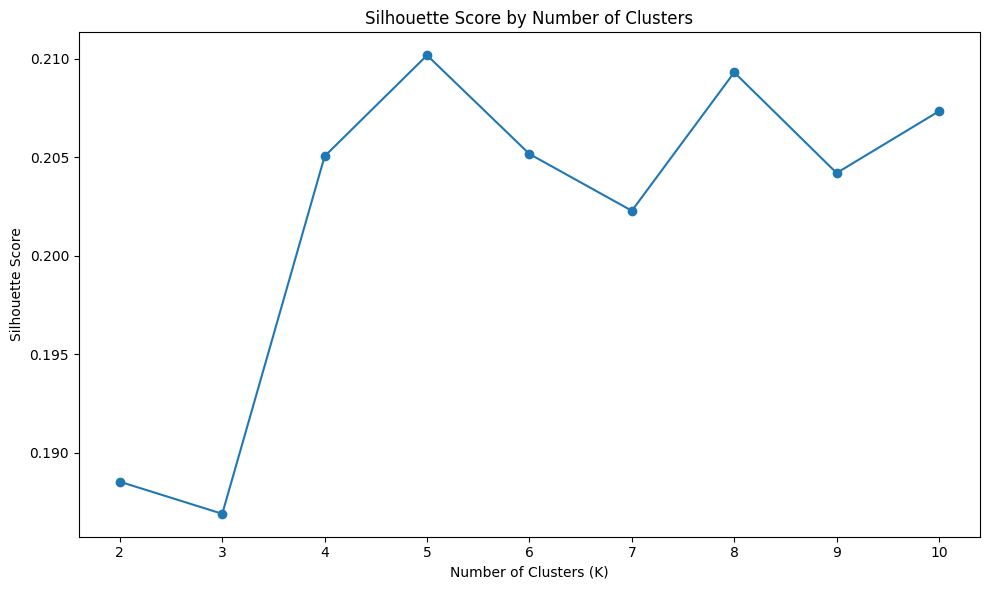

In [417]:
# Silhouette Score Visualization :

plt.figure(figsize=(10, 6))

plt.plot(
    silhouette_results["K"],
    silhouette_results["Silhouette_Score"],
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(range(2, 11))

plt.tight_layout()
plt.show()

In [418]:
# Final Cluster Profile :

final_cluster_profile = (
    df.groupby("Cluster")
    .agg(
        Product_Count=("product_id", "count"),
        Avg_Total_Sales=("Total_Sales", "mean"),
        Avg_Price=("price", "mean"),
        Avg_Rating=("review_score", "mean"),
        Avg_Review_Count=("review_count", "mean")
    )
    .round(2)
)

final_cluster_profile = final_cluster_profile.sort_values(
    "Avg_Total_Sales",
    ascending=False
)

display(final_cluster_profile)

,Product_Count,Avg_Total_Sales,Avg_Price,Avg_Rating,Avg_Review_Count
Cluster,,,,,
4,173,6680.13,375.20,3.21,781.54
3,211,6576.52,125.32,2.06,352.33
1,217,6064.99,347.16,3.71,259.05
0,230,5650.76,127.97,3.97,661.34
2,169,5093.66,305.08,1.89,642.81


## Exploratory K-Means Product Profiles

K-Means grouped products using total sales, price, review score, and review count. Since total sales was one of the inputs, the sales differences below are part of how the groups were formed. The silhouette score of about 0.21 indicates that the groups overlap, so these profiles should be treated as exploratory.

- **Cluster 4 — Higher sales and review activity:** 173 products; highest average sales (6,680), highest average review count (782), and highest average price (375). Its average rating is 3.21.
- **Cluster 3 — Higher sales, lower price:** 211 products; second-highest average sales (6,577) and lowest average price (125). Its average rating is low (2.06).
- **Cluster 1 — Higher-priced, relatively well-rated:** 217 products; average sales (6,065) are close to the dataset average. Its average price is 347 and average rating is 3.71.
- **Cluster 0 — Lower-priced, highest-rated:** 230 products; average sales (5,651) are below the dataset average. It has the highest average rating (3.97) and an average price of 128.
- **Cluster 2 — Lowest sales and rating:** 169 products; lowest average sales (5,094), lowest average rating (1.89), and an average price of 305.

These are averages for each group; individual products may differ. The profiles suggest questions for further investigation, but they do not establish why products sell more or prove that these are stable business segments.

## Business Recommendations from Product Performance Profiling

**Possible Business Ideas to Test**:

These clusters are exploratory: total sales was one of the clustering inputs, and the silhouette score of about 0.21 indicates that the groups overlap. The patterns below are ideas to investigate, not confirmed explanations or proven customer segments.

- **Cluster 4:** Had the highest average sales and review count in this dataset. A next analysis could check whether these products also have higher profit margins or more website visits.
- **Cluster 3:** Had high average sales and the lowest average price, but also a low average rating. Check profit margin and customer feedback before recommending a pricing or marketing change.
- **Cluster 0:** Had the highest average rating but lower average sales than Clusters 3 and 4. If traffic and conversion data become available, investigate whether customers are seeing and buying these products.
- **Cluster 2:** Had the lowest average sales and rating. Review customer feedback and profitability before deciding whether a product needs improvement or should be discontinued.

## Limitations and Future Improvements

### Limitations

- **Dataset source:** STAR AGILE provided this dataset for my capstone project.
- The dataset contains 1,000 products and 12 monthly sales columns. The meaning of “sales” (such as units sold, orders, or revenue) should be confirmed with the institute before making business interpretations.
- The tested prediction models did not meaningfully outperform the mean-only benchmark, so reliable sales prediction was not demonstrated with the available features.
- The five K-Means groups are exploratory. Their silhouette score of about 0.21 indicates that the groups overlap.
- The dataset does not include information such as inventory, discounts, advertising, website traffic, or profit margin. These factors could affect sales and business recommendations.
- The analysis describes patterns in this dataset; it does not prove that price, ratings, or reviews cause sales to change.

### Future Improvements

- Confirm the sales definition and other dataset details with STAR AGILE.
- If approved data with clear definitions is available, compare the results with it.
- Use dated data covering several years to study seasonality and test forecasts on later months.
- Add business information such as inventory, promotions, website traffic, conversion, and profit margin if available.
- Test whether the product groupings are stable before using them to guide business decisions.
